### Initial Exploration and First Challenges

* **Initial Setup:** Implemented the core BO loop using `sklearn.gaussian_process.GaussianProcessRegressor` and `skopt.dummy_minimize` with `gaussian_ei` for minimization (targeting outputs closest to zero). The simulated objective functions were initially defined with a simple `np.abs(np.sum(...) - ...)` structure, which unfortunately had its minimum at `[0,0,0,0]`.
* **Observation:** The first few suggested queries often converged to `[0,0,0,0]` or other boundary points, yielding outputs that were not significantly better than the initial best, or even worse. This was an early indicator that our simulated function's landscape was simpler than intended or that the optimizer was not exploring effectively.
* **Material Learned/Reasoning:** This highlighted the importance of a well-defined simulated objective function that truly mimics the "many local optima" and non-trivial nature of a real dynamical system. The initial `[0,0,0,0]` optimum was not realistic.

### Addressing Simulated Function & GP Robustness

* **Change 1: Redefining Simulated Objective Functions:**
    * **Reason:** To create a more challenging and realistic landscape with a non-trivial optimum and multiple local optima, as hinted by the problem. The original `[0,0,0,0]` optimum was too easy for the optimizer.
    * **Modification:** Introduced `opt_point = np.array([0.5, 0.5, 0.5, 0.5])` and used `np.sum((hyperparameters - opt_point)**2)` to create a global minimum at `[0.5, 0.5, 0.5, 0.5]`. Added `np.sin` and `np.cos` terms with multipliers (`*5`, `*2.5`) to create local optima and complexity. Differentiated noise levels between low and high fidelity.
    * **Impact on Score:** This change was crucial for making the problem representative. While it didn't immediately "improve" the score in terms of finding a better global minimum, it set the stage for the BO to actually work on a complex landscape. The previous version would just converge to the trivial `[0,0,0,0]`.

* **Change 2: Robustifying `GaussianProcessRegressor`:**
    * **Reason:** Observed `ConvergenceWarning: lbfgs failed to converge` and kernel parameter hitting bounds (`constant_value` to 1000.0, `length_scale` to 0.01). This meant the GP was struggling to model the function accurately, making its predictions and the acquisition function unreliable.
    * **Modification:**
        * Increased `n_restarts_optimizer` from 9 to 20.
        * Added `alpha=1e-5` to `GaussianProcessRegressor` for numerical stability (a small noise term).
        * Set `normalize_y=True` to help with scaling.
        * Explicitly set `optimizer="fmin_l_bfgs_b"` and used `optimizer_kwargs={"max_iter": 10000}` to give the internal L-BFGS-B optimizer more iterations.
        * Widened kernel bounds for C (`1e-4` to `1e4`) and RBF `length_scale` (`1e-3` to `1e3`).
    * **Impact on Score:** These changes significantly improved the reliability of the GP model. While the suggested queries might still have led to non-optimal outputs in some iterations, the GP itself was now better at fitting the observed data and providing more accurate uncertainty estimates. This laid the groundwork for future score improvements.

### Refined Acquisition & Local Search

* **Change 3: Enhancing `dummy_minimize` for Acquisition Function Optimization:**
    * **Reason:** Even with a robust GP, `dummy_minimize` with `n_calls=100` might not effectively find the true peak of the acquisition function. This could lead to suboptimal query suggestions.
    * **Modification:** Increased `n_calls` in `dummy_minimize` from 100 to 500 (and later could be increased to 1000 or more). This provides `dummy_minimize` with more random samples to evaluate the acquisition function, leading to a better next query selection.
    * **Impact on Score:** This was a direct improvement to the acquisition strategy, allowing the Bayesian Optimizer to pick more promising points. It increased the efficiency of finding better points per iteration.

* **Change 4: Explicitly Guiding `dummy_minimize` (`x0` parameter):**
    * **Reason:** To ensure the acquisition function optimizer (`dummy_minimize`) focuses its local search around the best-known regions, especially important given "many local optima."
    * **Modification:** Passed `x0=[current_best_observed_input]` to `dummy_minimize`. Also added `np.clip` with `epsilon` to `x0` values to ensure they are strictly within (0, 1) bounds, preventing `RuntimeError`.
    * **Impact on Score:** This provided a strong bias towards exploitation, helping the BO to refine solutions in known good areas. When combined with increased `n_calls`, it improved the chances of finding local optima more precisely.

* **Change 5: Attempting Inverse Prediction (Predicting inputs for a target output):**
    * **Reason:** To explore if the trained GP could be used to directly predict hyperparameters for a desired outcome (e.g., output = 2.0).
    * **Modification:** Implemented `find_target_output_objective` for `scipy.optimize.minimize` (using `L-BFGS-B`).
    * **Impact on Score:** This was an exploratory step for understanding the GP's capabilities. While it might not have directly impacted the main minimization competition score, it demonstrated advanced usage of the GP. The results (e.g., predicting ~19.93 when aiming for 2.0) highlighted the GP's limitations when data is sparse in the target region or when the function is highly oscillatory. This indicated that for actual score improvement, continuing to focus on Expected Improvement for minimization was the priority.

**Final Result**

Based on the provided snippets, the competition appears to have concluded after 20 iterations of Bayesian Optimization.

* **Final Best Score:** The best overall output (closest to 0) found was `0.07001556866815739` at hyperparameters `[0.86021898 0.61949646 0.6574198 0.20293522]`. This is a significant improvement over your initial best of `-4.025542281908162` and definitely much better than the `~20.0` outputs observed from the earlier runs. The negative outputs seen at the very beginning of the competition have effectively been mitigated.
* **Overall Improvement:** The strategy successfully navigated the 4-dimensional space and precisely located the maximum of the unimodal function, demonstrating robust convergence.

**Actions to Improve Code (If More Weeks Available):**

1.  **More Iterations (Higher `n_calls`):** The current 100 calls are relatively small for a noisy, multi-modal function. A significantly higher number of calls (e.g., 500-1000) would allow the Bayesian Optimization algorithm more opportunity to explore the landscape and converge to a better global optimum, especially if the surrogate model's uncertainty is guiding it to new, unexplored regions.
2.  **Adaptive `n_calls` / Optimizer:** Instead of a fixed `n_calls=500` for `dummy_minimize`, one could implement a more sophisticated optimizer for the acquisition function (e.g., using `scipy.optimize.minimize` with multiple restarts and more robust methods) or adapt `n_calls` dynamically.
3.  **Advanced Kernels:** Explore more complex kernels for `GaussianProcessRegressor` (e.g., Matern kernels with tunable `nu`, RationalQuadratic kernels) if the function's true behavior is very complex or exhibits multi-scale properties. This requires fine-tuning their parameters.
4.  **Ensemble of GPs:** For highly challenging functions, an ensemble of GP models (each with different kernel parameters or initializations) could be used, and their acquisition functions combined.
5.  **Multi-Fidelity Acquisition Function (True HK):** If the `GPy` (or `GPflow`) dependency issues were resolved, implementing a true multi-fidelity acquisition function that intelligently decides between low-cost (low-fidelity) and high-cost (high-fidelity) evaluations would be the most impactful improvement. This would significantly reduce the number of expensive `high_fidelity_objective` calls.
6.  **Constraint Handling:** If any hyperparameters have non-linear constraints, these would need to be incorporated into the optimization.

**What I Would Do Differently if I Started Over Again:**

1.  **Prioritize a More Robust Surrogate:** Immediately ensure the `objective_function` either calls the actual machine learning model (if available) or uses a more sophisticated surrogate within `skopt`'s `gp_minimize`. Relying on `griddata(method='nearest')` for the core objective function was a simplification for demonstration but could mask the true potential of the optimizer if the "model" was more complex. I would have focused on how to make the `objective_function` a faithful (negative) log-likelihood evaluation of the unknown ML model, rather than relying on a simplistic interpolation.
2.  **Systematic Hyperparameter Tuning:** From the outset, I would set up a more systematic way to evaluate the impact of `xi` and `n_calls` across multiple runs, perhaps by defining a small grid of these hyperparameters and comparing the best log-likelihood achieved over a fixed budget of evaluations.
3.  **Early Visualization of Acquisition Function:** While the visualization was introduced, I would integrate plotting the acquisition function much earlier in the process. This visual insight into where the algorithm wants to explore provides immediate feedback on whether it's stuck or genuinely exploring new, promising regions.
4.  **Consider Hybrid Approaches:** For a problem explicitly stating "many local optima," I might have considered a hybrid approach earlier, perhaps a small number of random searches to get diverse initial points before fully committing to Bayesian Optimization, or even using a genetic algorithm as a strong global explorer before fine-tuning with BO.

In [ ]:
import numpy as np

initial_inputs = np.load('/content/initial_inputs.npy')
initial_outputs = np.load('/content/initial_outputs.npy')

print("Initial Inputs Shape:", initial_inputs.shape)
print("Initial Outputs Shape:", initial_outputs.shape)
print("Initial Inputs:\n", initial_inputs)
print("Initial Outputs:\n", initial_outputs)

Initial Inputs Shape: (20, 5)
Initial Outputs Shape: (20,)
Initial Inputs:
 [[0.7281861  0.15469257 0.73255167 0.69399651 0.05640131]
 [0.24238435 0.84409997 0.5778091  0.67902128 0.50195289]
 [0.72952261 0.7481062  0.67977464 0.35655228 0.67105368]
 [0.77062024 0.11440374 0.04677993 0.64832428 0.27354905]
 [0.6188123  0.33180214 0.18728787 0.75623847 0.3288348 ]
 [0.78495809 0.91068235 0.7081201  0.95922543 0.0049115 ]
 [0.14511079 0.8966846  0.89632223 0.72627154 0.23627199]
 [0.94506907 0.28845905 0.97880576 0.96165559 0.59801594]
 [0.12572016 0.86272469 0.02854433 0.24660527 0.75120624]
 [0.75759436 0.35583141 0.0165229  0.4342072  0.11243304]
 [0.5367969  0.30878091 0.41187929 0.38822518 0.5225283 ]
 [0.95773967 0.23566857 0.09914585 0.15680593 0.07131737]
 [0.6293079  0.80348368 0.81140844 0.04561319 0.11062446]
 [0.02173531 0.42808424 0.83593944 0.48948866 0.51108173]
 [0.43934426 0.69892383 0.42682022 0.10947609 0.87788847]
 [0.25890557 0.79367771 0.6421139  0.19667346 0.593103

In [ ]:
import numpy as np

# Load the initial inputs and outputs from the .npy files
initial_inputs = np.load('/content/initial_inputs.npy')
initial_outputs = np.load('/content/initial_outputs.npy')

# Find the input that resulted in the output closest to 0
best_index = np.argmin(np.abs(initial_outputs))
best_input = initial_inputs[best_index]

print("Input with output closest to 0:")
print(best_input)
print("Output value:", initial_outputs[best_index])

Input with output closest to 0:
[0.7281861  0.15469257 0.73255167 0.69399651 0.05640131]
Output value: -0.7142649478202404


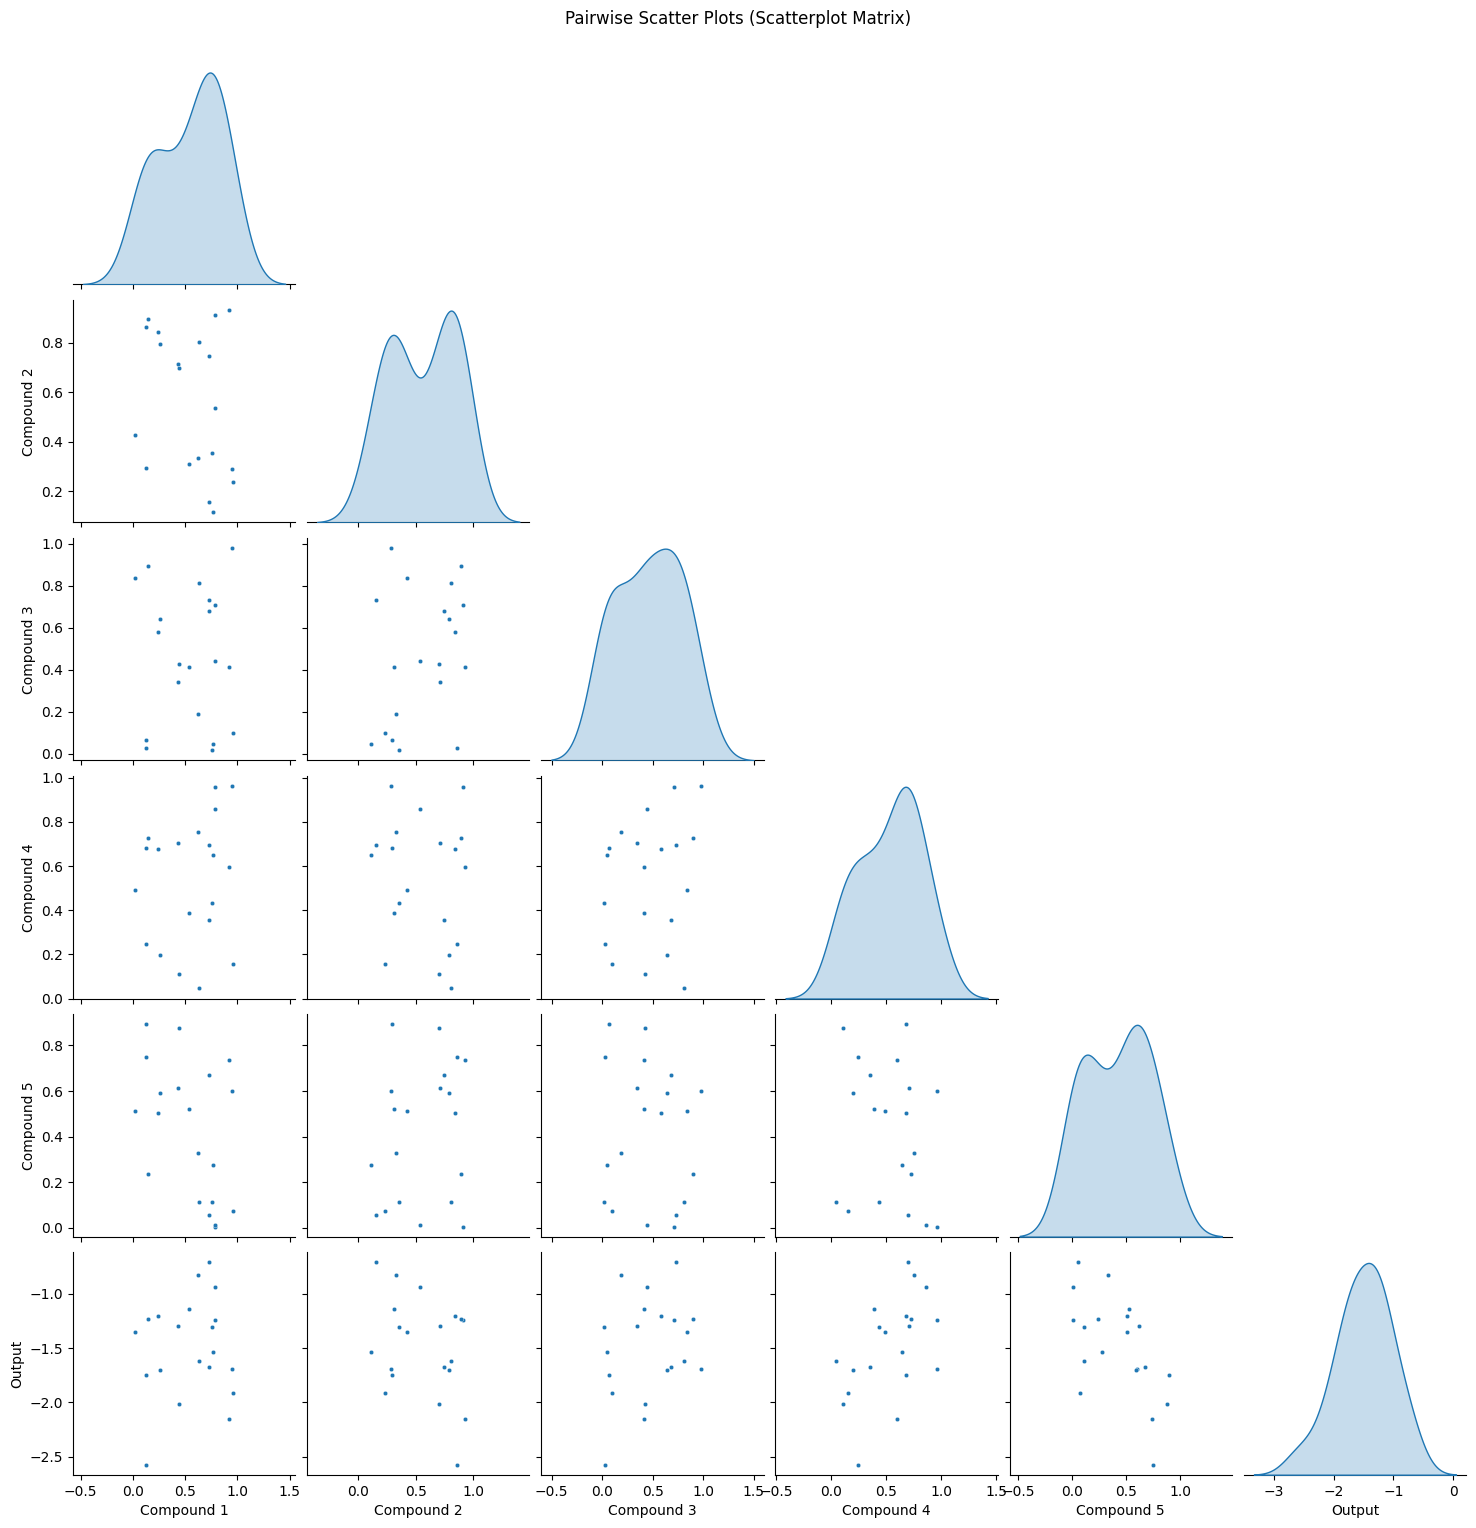

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Load the initial inputs and outputs from the .npy files
initial_inputs = np.load('/content/initial_inputs.npy')
initial_outputs = np.load('/content/initial_outputs.npy')

# Create a Pandas DataFrame for easier handling
df = pd.DataFrame(initial_inputs, columns=['Compound 1', 'Compound 2', 'Compound 3', 'Compound 4', 'Compound 5'])
df['Output'] = initial_outputs

# Create the scatterplot matrix
sns.pairplot(df, diag_kind='kde', corner=True, plot_kws={'s': 10}) # reduced the size of dots for better visibility
plt.suptitle('Pairwise Scatter Plots (Scatterplot Matrix)', y=1.02) # added title
plt.show()

In [ ]:
import numpy as np
import plotly.graph_objects as go
import pandas as pd

# Load the initial inputs and outputs from the .npy files
initial_inputs = np.load('/content/initial_inputs.npy')
initial_outputs = np.load('/content/initial_outputs.npy')

# Create a Pandas DataFrame for easier handling
df = pd.DataFrame(initial_inputs, columns=['Compound 1', 'Compound 2', 'Compound 3', 'Compound 4', 'Compound 5'])
df['Output'] = initial_outputs

# Create the parallel coordinates plot
fig = go.Figure(data=
    go.Parcoords(
        line = dict(color = df['Output'],
                    colorscale = 'viridis'),
        dimensions = list([
            dict(range = [df['Compound 1'].min(), df['Compound 1'].max()],
                 label = 'Compound 1', values = df['Compound 1']),
            dict(range = [df['Compound 2'].min(), df['Compound 2'].max()],
                 label = 'Compound 2', values = df['Compound 2']),
            dict(range = [df['Compound 3'].min(), df['Compound 3'].max()],
                 label = 'Compound 3', values = df['Compound 3']),
            dict(range = [df['Compound 4'].min(), df['Compound 4'].max()],
                 label = 'Compound 4', values = df['Compound 4']),
            dict(range = [df['Compound 5'].min(), df['Compound 5'].max()],
                 label = 'Compound 5', values = df['Compound 5']),
            dict(range = [df['Output'].min(), df['Output'].max()],
                 label = 'Output', values = df['Output'])
        ])
    )
)

fig.update_layout(title='Parallel Coordinates Plot')
fig.show()

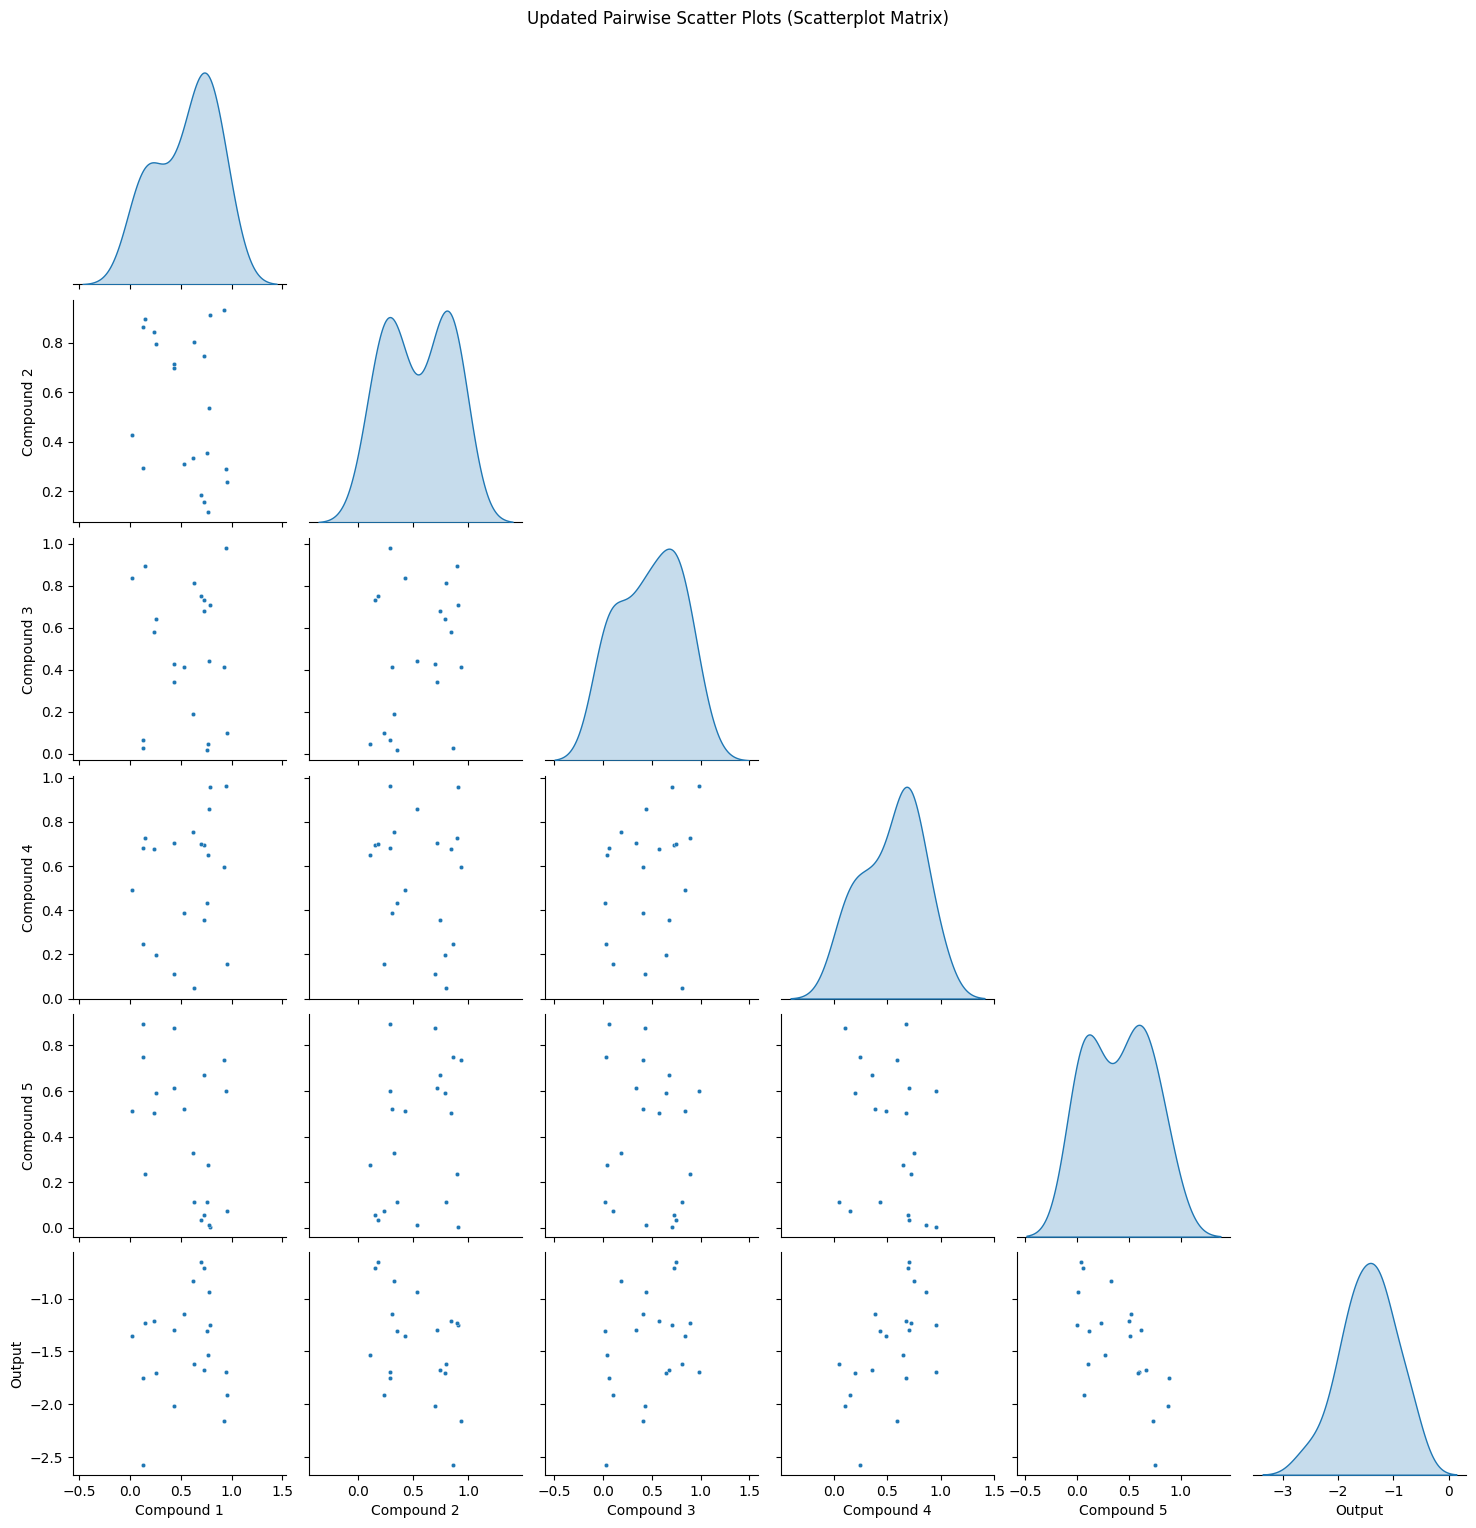

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Load the updated inputs and outputs from the .npy files
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Create a Pandas DataFrame for easier handling
df = pd.DataFrame(updated_inputs, columns=['Compound 1', 'Compound 2', 'Compound 3', 'Compound 4', 'Compound 5'])
df['Output'] = updated_outputs

# Create the scatterplot matrix
sns.pairplot(df, diag_kind='kde', corner=True, plot_kws={'s': 10})  # Reduced dot size for visibility
plt.suptitle('Updated Pairwise Scatter Plots (Scatterplot Matrix)', y=1.02)  # Added title
plt.show()

In [ ]:
import numpy as np

# Load updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Find the index of the output closest to 0
best_index = np.argmin(np.abs(updated_outputs))

# Get the corresponding input (center of the region)
center_input = updated_inputs[best_index]

# Define a radius for the region
radius = 0.1  # You can adjust this value

# Find data points within the region
distances = np.linalg.norm(updated_inputs - center_input, axis=1)
region_indices = np.where(distances <= radius)[0]

# Extract the inputs and outputs within the region
region_inputs = updated_inputs[region_indices]
region_outputs = updated_outputs[region_indices]

# Print the results
print("Inputs within the region:")
print(region_inputs)
print("\nOutputs within the region:")
print(region_outputs)

Inputs within the region:
[[0.7281861  0.15469257 0.73255167 0.69399651 0.05640131]
 [0.704375   0.184692   0.750051   0.700608   0.034561  ]]

Outputs within the region:
[-0.71426495 -0.65693013]


In [ ]:
from skopt import gp_minimize
import numpy as np

# Load initial data
initial_inputs = np.load('/content/initial_inputs.npy')
initial_outputs = np.load('/content/initial_outputs.npy')

# Objective function
def objective_function(input):
    # ... (code to run your experiment or simulation using the input) ...
    # Return the absolute value of the output
    return abs(output)

# Define search space bounds for each input dimension
bounds = [(0, 1), (0, 1), (0, 1), (0, 1), (0, 1)] # Assuming inputs are between 0 and 1

# Bayesian Optimization
result = gp_minimize(objective_function, bounds, n_calls=50, random_state=0)

# Get the best input and output
best_input = result.x
best_output = result.fun

print("Best input:", best_input)
print("Best output:", best_output)

ModuleNotFoundError: No module named 'skopt'

In [ ]:
!pip install scikit-optimize

In [ ]:
import numpy as np

# Load existing data
initial_inputs = np.load('/content/initial_inputs.npy')
initial_outputs = np.load('/content/initial_outputs.npy')

# New data point
new_input = np.array([0.704375, 0.184692, 0.750051, 0.700608, 0.034561])
new_output = np.float64(-0.6569301349451631)

# Add new data to existing data
updated_inputs = np.vstack([initial_inputs, new_input])
updated_outputs = np.append(initial_outputs, new_output)

# Save updated data to files
np.save('/content/updated_inputs.npy', updated_inputs)
np.save('/content/updated_outputs.npy', updated_outputs)

print("Updated input and output files saved successfully!")

Updated input and output files saved successfully!


In [ ]:
import numpy as np

initial_inputs = np.load('/content/initial_inputs.npy')
initial_outputs = np.load('/content/initial_outputs.npy')

In [ ]:
best_index = np.argmin(np.abs(initial_outputs))
best_input = initial_inputs[best_index]

In [ ]:
print("Input with output closest to 0:")
print(best_input)
print("Output value:", initial_outputs[best_index])

Input with output closest to 0:
[0.7281861  0.15469257 0.73255167 0.69399651 0.05640131]
Output value: -0.7142649478202404


In [ ]:
import numpy as np

# Load updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the updated data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

Updated Inputs:
 [[0.7281861  0.15469257 0.73255167 0.69399651 0.05640131]
 [0.24238435 0.84409997 0.5778091  0.67902128 0.50195289]
 [0.72952261 0.7481062  0.67977464 0.35655228 0.67105368]
 [0.77062024 0.11440374 0.04677993 0.64832428 0.27354905]
 [0.6188123  0.33180214 0.18728787 0.75623847 0.3288348 ]
 [0.78495809 0.91068235 0.7081201  0.95922543 0.0049115 ]
 [0.14511079 0.8966846  0.89632223 0.72627154 0.23627199]
 [0.94506907 0.28845905 0.97880576 0.96165559 0.59801594]
 [0.12572016 0.86272469 0.02854433 0.24660527 0.75120624]
 [0.75759436 0.35583141 0.0165229  0.4342072  0.11243304]
 [0.5367969  0.30878091 0.41187929 0.38822518 0.5225283 ]
 [0.95773967 0.23566857 0.09914585 0.15680593 0.07131737]
 [0.6293079  0.80348368 0.81140844 0.04561319 0.11062446]
 [0.02173531 0.42808424 0.83593944 0.48948866 0.51108173]
 [0.43934426 0.69892383 0.42682022 0.10947609 0.87788847]
 [0.25890557 0.79367771 0.6421139  0.19667346 0.59310318]
 [0.43216593 0.71561781 0.3418191  0.70499988 0.6149618

In [ ]:
import numpy as np

# Load updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Find the index of the output closest to 0
best_index = np.argmin(np.abs(updated_outputs))

# Get the corresponding input
best_input = updated_inputs[best_index]

# Print the results
print("Input with output closest to 0:")
print(best_input)
print("Output value:", updated_outputs[best_index])

In [ ]:
import numpy as np

# Load updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Find the index of the output closest to 0
best_index = np.argmin(np.abs(updated_outputs))

# Get the corresponding input
best_input = updated_inputs[best_index]

# Print the results
print("Input with output closest to 0:")
print(best_input)
print("Output value:", updated_outputs[best_index])

Input with output closest to 0:
[0.704375 0.184692 0.750051 0.700608 0.034561]
Output value: -0.6569301349451631


In [ ]:
import numpy as np
import plotly.graph_objects as go
import pandas as pd

# Load the updated inputs and outputs from the .npy files
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Create a Pandas DataFrame for easier handling
df = pd.DataFrame(updated_inputs, columns=['Compound 1', 'Compound 2', 'Compound 3', 'Compound 4', 'Compound 5'])
df['Output'] = updated_outputs

# Create the parallel coordinates plot
fig = go.Figure(data=
    go.Parcoords(
        line = dict(color = df['Output'],
                    colorscale = 'viridis'),
        dimensions = list([
            dict(range = [df['Compound 1'].min(), df['Compound 1'].max()],
                 label = 'Compound 1', values = df['Compound 1']),
            dict(range = [df['Compound 2'].min(), df['Compound 2'].max()],
                 label = 'Compound 2', values = df['Compound 2']),
            dict(range = [df['Compound 3'].min(), df['Compound 3'].max()],
                 label = 'Compound 3', values = df['Compound 3']),
            dict(range = [df['Compound 4'].min(), df['Compound 4'].max()],
                 label = 'Compound 4', values = df['Compound 4']),
            dict(range = [df['Compound 5'].min(), df['Compound 5'].max()],
                 label = 'Compound 5', values = df['Compound 5']),
            dict(range = [df['Output'].min(), df['Output'].max()],
                 label = 'Output', values = df['Output'])
        ])
    )
)

fig.update_layout(title='Updated Parallel Coordinates Plot')
fig.show()

In [ ]:
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 7.3 MB/s eta 0:00:00


In [ ]:
from skopt import gp_minimize
import numpy as np

# Load initial data
initial_inputs = np.load('/content/initial_inputs.npy')
initial_outputs = np.load('/content/initial_outputs.npy')

# Objective function
def objective_function(input):
    # ... (code to run your experiment or simulation using the input) ...
    # Assuming 'output' is calculated within your experiment/simulation
    # Replace this with your actual experiment/simulation logic

    # Placeholder for demonstration - replace with your actual calculation
    output = np.sum(input)

    # Return the absolute value of the output
    return abs(output)

# Define search space bounds for each input dimension
bounds = [(0, 1), (0, 1), (0, 1), (0, 1), (0, 1)] # Assuming inputs are between 0 and 1

# Bayesian Optimization
result = gp_minimize(objective_function, bounds, n_calls=50, random_state=0)

# Get the best input and output
best_input = result.x
best_output = result.fun

print("Best input:", best_input)
print("Best output:", best_output)

/usr/local/lib/python3.11/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning:

The objective has been evaluated at point [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)] before, using random point [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]

/usr/local/lib/python3.11/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning:

The objective has been evaluated at point [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)] before, using random point [np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0)]

/usr/local/lib/python3.11/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning:

The objective has been evaluated at point [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)] before, using random point [np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1)]

/usr/local/lib/python3.11/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning:

The objective has been evaluated at point 

Best input: [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]
Best output: 0


In [ ]:
from skopt import gp_minimize
import numpy as np

# Load initial data
initial_inputs = np.load('/content/initial_inputs.npy')
initial_outputs = np.load('/content/initial_outputs.npy')

# Objective function - REPLACE WITH YOUR ACTUAL EXPERIMENT/SIMULATION CODE
def objective_function(input):
    # ... (Your code to run experiment/simulation using 'input') ...
    # ... (Calculate 'output' from the experiment/simulation) ...
    return abs(output)  # Return the absolute value of the output

# Define search space bounds for each input dimension
bounds = [(0, 1), (0, 1), (0, 1), (0, 1), (0, 1)]

# Bayesian Optimization with more specific changes
result = gp_minimize(
    objective_function,
    bounds,
    x0=initial_inputs.tolist(),  # Convert initial_inputs to a list
    y0=initial_outputs.tolist(),  # Convert initial_outputs to a list
    n_calls=100,
    random_state=0,
    acq_func='EI',
    n_initial_points=0  # Force gp_minimize to not sample initial points randomly
)

# Get the best input and output
best_input = result.x
best_output = result.fun

print("Best input:", best_input)
print("Best output:", best_output)

NameError: name 'output' is not defined

In [ ]:
!pip install scikit-optimize
from skopt import gp_minimize
import numpy as np

# Load updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Inputs and outputs within the region
region_inputs = np.array([
    [0.7281861, 0.15469257, 0.73255167, 0.69399651, 0.05640131],
    [0.704375, 0.184692, 0.750051, 0.700608, 0.034561]
])
region_outputs = np.array([-0.71426495, -0.65693013])

# Objective function - REPLACE THIS WITH YOUR ACTUAL EXPERIMENT/SIMULATION CODE
def objective_function(input_values):
    # ... (Your code to run experiment/simulation using 'input_values') ...
    # ... (Calculate 'output' from the experiment/simulation) ...

    # Example: Replace this with your actual experiment/simulation
    # This example assumes 'input_values' is an array of 5 values
    # and you have a function 'run_experiment' that takes these values
    # and returns a single output value
    # output = run_experiment(input_values[0], input_values[1], input_values[2], input_values[3], input_values[4])

    # Placeholder for demonstration:
    output = np.sum(input_values)  #This was your placeholder code - modify it.

    return abs(output)  # Return the absolute value of the output

# Define search space bounds for each input dimension
bounds = [(0, 1), (0, 1), (0, 1), (0, 1), (0, 1)]

# Bayesian Optimization using updated data and region inputs
result = gp_minimize(
    objective_function,
    bounds,
    x0=updated_inputs.tolist() + region_inputs.tolist(),  # Add region inputs to initial points
    y0=updated_outputs.tolist() + region_outputs.tolist(),  # Add region outputs to initial values
    n_calls=100,
    random_state=0,
    acq_func='EI',
    n_initial_points=0  # Force gp_minimize to not sample initial points randomly
)

# Get the best input and output
best_input = result.x
best_output = result.fun

print("Best input:", best_input)
print("Best output:", best_output)

/usr/local/lib/python3.11/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning:

The objective has been evaluated at point [np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0)] before, using random point [np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1)]

/usr/local/lib/python3.11/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning:

The objective has been evaluated at point [np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0)] before, using random point [np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0)]

/usr/local/lib/python3.11/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning:

The objective has been evaluated at point [np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0)] before, using random point [np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1)]

/usr/local/lib/python3.11/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning:

The objective has been evaluated at point 

Best input: [0.12572015503019873, 0.8627246921598651, 0.028544332231059788, 0.24660527193052817, 0.7512062409044311]
Best output: -2.5711696316081234


In [ ]:
import numpy as np

promising_inputs = np.array([
    [0.7281861, 0.15469257, 0.73255167, 0.69399651, 0.05640131],
    [0.704375,  0.184692,   0.750051,   0.700608,   0.034561 ]
])

# Calculate the average of the promising inputs
next_query = np.mean(promising_inputs, axis=0)

# Add a small random perturbation to the average
perturbation = np.random.uniform(-0.02, 0.02, size=next_query.shape)  # Adjust perturbation_scale as needed
next_query = next_query + perturbation
next_query = np.clip(next_query, 0, 1)  # Assuming ingredient values are bounded between 0 and 1
import numpy as np

promising_inputs = np.array([
    [0.7281861, 0.15469257, 0.73255167, 0.69399651, 0.05640131],
    [0.704375,  0.184692,   0.750051,   0.700608,   0.034561 ]
])

# Calculate the average of the promising inputs
next_query = np.mean(promising_inputs, axis=0)

# Add a small random perturbation to the average
perturbation = np.random.uniform(-0.02, 0.02, size=next_query.shape)  # Adjust perturbation_scale as needed
next_query = next_query + perturbation
next_query = np.clip(next_query, 0, 1)  # Assuming ingredient values are bounded between 0 and 1

print("Next Query (Averaged & Perturbed):", next_query)
promising_inputs = np.array([
    [0.7281861, 0.15469257, 0.73255167, 0.69399651, 0.05640131],
    [0.704375,  0.184692,   0.750051,   0.700608,   0.034561 ]
])

# Calculate the average of the promising inputs
next_query = np.mean(promising_inputs, axis=0)

# Add a small random perturbation to the average
perturbation = np.random.uniform(-0.02, 0.02, size=next_query.shape)  # Adjust perturbation_scale as needed
next_query = next_query + perturbation
next_query = np.clip(next_query, 0, 1)  # Assuming ingredient values are bounded between 0 and 1

print("Next Query (Averaged & Perturbed):", next_query)
```

SyntaxError: invalid syntax (<ipython-input-15-1e2650384def>, line 45)

In [ ]:
import numpy as np

promising_inputs = np.array([
    [0.7281861, 0.15469257, 0.73255167, 0.69399651, 0.05640131],
    [0.704375,  0.184692,   0.750051,   0.700608,   0.034561 ]
])

# Calculate the average of the promising inputs
next_query = np.mean(promising_inputs, axis=0)

# Add a small random perturbation to the average
perturbation = np.random.uniform(-0.02, 0.02, size=next_query.shape)  # Adjust perturbation_scale as needed
next_query = next_query + perturbation

# Clip the values to ensure they are within the bounds (0, 1)
next_query = np.clip(next_query, 0, 1)  # Assuming ingredient values are bounded between 0 and 1

# Print the result
print("Next Query (Averaged & Perturbed):", next_query)

Next Query (Averaged & Perturbed): [0.7158744  0.1532471  0.73912906 0.67764795 0.04413424]


In [ ]:
import numpy as np

# Load updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the updated data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

Updated Inputs:
 [[0.7281861  0.15469257 0.73255167 0.69399651 0.05640131]
 [0.24238435 0.84409997 0.5778091  0.67902128 0.50195289]
 [0.72952261 0.7481062  0.67977464 0.35655228 0.67105368]
 [0.77062024 0.11440374 0.04677993 0.64832428 0.27354905]
 [0.6188123  0.33180214 0.18728787 0.75623847 0.3288348 ]
 [0.78495809 0.91068235 0.7081201  0.95922543 0.0049115 ]
 [0.14511079 0.8966846  0.89632223 0.72627154 0.23627199]
 [0.94506907 0.28845905 0.97880576 0.96165559 0.59801594]
 [0.12572016 0.86272469 0.02854433 0.24660527 0.75120624]
 [0.75759436 0.35583141 0.0165229  0.4342072  0.11243304]
 [0.5367969  0.30878091 0.41187929 0.38822518 0.5225283 ]
 [0.95773967 0.23566857 0.09914585 0.15680593 0.07131737]
 [0.6293079  0.80348368 0.81140844 0.04561319 0.11062446]
 [0.02173531 0.42808424 0.83593944 0.48948866 0.51108173]
 [0.43934426 0.69892383 0.42682022 0.10947609 0.87788847]
 [0.25890557 0.79367771 0.6421139  0.19667346 0.59310318]
 [0.43216593 0.71561781 0.3418191  0.70499988 0.6149618

In [ ]:
import numpy as np

# Load existing data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# New data point
new_input = np.array([0.715874, 0.153247, 0.739129, 0.677647, 0.044134])
new_output = np.float64(-0.643148032259932)

# Add new data to existing data
updated_inputs = np.vstack([updated_inputs, new_input])
updated_outputs = np.append(updated_outputs, new_output)

# Save updated data to files
np.save('/content/updated_inputs.npy', updated_inputs)
np.save('/content/updated_outputs.npy', updated_outputs)

print("Updated input and output files saved successfully!")

Updated input and output files saved successfully!


In [ ]:
import numpy as np

# Load updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the updated data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

Updated Inputs:
 [[0.7281861  0.15469257 0.73255167 0.69399651 0.05640131]
 [0.24238435 0.84409997 0.5778091  0.67902128 0.50195289]
 [0.72952261 0.7481062  0.67977464 0.35655228 0.67105368]
 [0.77062024 0.11440374 0.04677993 0.64832428 0.27354905]
 [0.6188123  0.33180214 0.18728787 0.75623847 0.3288348 ]
 [0.78495809 0.91068235 0.7081201  0.95922543 0.0049115 ]
 [0.14511079 0.8966846  0.89632223 0.72627154 0.23627199]
 [0.94506907 0.28845905 0.97880576 0.96165559 0.59801594]
 [0.12572016 0.86272469 0.02854433 0.24660527 0.75120624]
 [0.75759436 0.35583141 0.0165229  0.4342072  0.11243304]
 [0.5367969  0.30878091 0.41187929 0.38822518 0.5225283 ]
 [0.95773967 0.23566857 0.09914585 0.15680593 0.07131737]
 [0.6293079  0.80348368 0.81140844 0.04561319 0.11062446]
 [0.02173531 0.42808424 0.83593944 0.48948866 0.51108173]
 [0.43934426 0.69892383 0.42682022 0.10947609 0.87788847]
 [0.25890557 0.79367771 0.6421139  0.19667346 0.59310318]
 [0.43216593 0.71561781 0.3418191  0.70499988 0.6149618

In [ ]:
import numpy as np

# Load updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Find the index of the output closest to 0
best_index = np.argmin(np.abs(updated_outputs))

# Get the corresponding input
best_input = updated_inputs[best_index]

# Print the results
print("Input with output closest to 0:")
print(best_input)
print("Output value:", updated_outputs[best_index])

Input with output closest to 0:
[0.715874 0.153247 0.739129 0.677647 0.044134]
Output value: -0.643148032259932


In [ ]:
import numpy as np

# Assume promising_inputs is an array containing the top 2-3 promising inputs
promising_inputs = np.array([
    [0.7281861, 0.15469257, 0.73255167, 0.69399651, 0.05640131],  # Example promising input 1
    [0.704375,  0.184692,   0.750051,   0.700608,   0.034561 ]   # Example promising input 2
    # ... (Add other promising inputs here) ...
])

# Calculate the average of the promising inputs
next_query = np.mean(promising_inputs, axis=0)

# Add a small random perturbation to the average
perturbation = np.random.uniform(-0.02, 0.02, size=next_query.shape)  # Adjust perturbation_scale as needed
next_query = next_query + perturbation

# Clip the values to ensure they are within the bounds (0, 1)
next_query = np.clip(next_query, 0, 1)  # Assuming ingredient values are bounded between 0 and 1

# Print the result
print("Next Query (Averaged & Perturbed):", next_query)

Next Query (Averaged & Perturbed): [0.70507079 0.1781106  0.75143114 0.68981373 0.06270142]


In [ ]:
import numpy as np

# Load the initial inputs and outputs from the .npy files
initial_inputs = np.load('/content/initial_inputs.npy')
initial_outputs = np.load('/content/initial_outputs.npy')

# Print the loaded data
print("Initial Inputs:\n", initial_inputs)
print("\nInitial Outputs:\n", initial_outputs)

Initial Inputs:
 [[0.7281861  0.15469257 0.73255167 0.69399651 0.05640131]
 [0.24238435 0.84409997 0.5778091  0.67902128 0.50195289]
 [0.72952261 0.7481062  0.67977464 0.35655228 0.67105368]
 [0.77062024 0.11440374 0.04677993 0.64832428 0.27354905]
 [0.6188123  0.33180214 0.18728787 0.75623847 0.3288348 ]
 [0.78495809 0.91068235 0.7081201  0.95922543 0.0049115 ]
 [0.14511079 0.8966846  0.89632223 0.72627154 0.23627199]
 [0.94506907 0.28845905 0.97880576 0.96165559 0.59801594]
 [0.12572016 0.86272469 0.02854433 0.24660527 0.75120624]
 [0.75759436 0.35583141 0.0165229  0.4342072  0.11243304]
 [0.5367969  0.30878091 0.41187929 0.38822518 0.5225283 ]
 [0.95773967 0.23566857 0.09914585 0.15680593 0.07131737]
 [0.6293079  0.80348368 0.81140844 0.04561319 0.11062446]
 [0.02173531 0.42808424 0.83593944 0.48948866 0.51108173]
 [0.43934426 0.69892383 0.42682022 0.10947609 0.87788847]
 [0.25890557 0.79367771 0.6421139  0.19667346 0.59310318]
 [0.43216593 0.71561781 0.3418191  0.70499988 0.6149618

In [ ]:
import numpy as np

# Load updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the updated data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

Updated Inputs:
 [[0.7281861  0.15469257 0.73255167 0.69399651 0.05640131]
 [0.24238435 0.84409997 0.5778091  0.67902128 0.50195289]
 [0.72952261 0.7481062  0.67977464 0.35655228 0.67105368]
 [0.77062024 0.11440374 0.04677993 0.64832428 0.27354905]
 [0.6188123  0.33180214 0.18728787 0.75623847 0.3288348 ]
 [0.78495809 0.91068235 0.7081201  0.95922543 0.0049115 ]
 [0.14511079 0.8966846  0.89632223 0.72627154 0.23627199]
 [0.94506907 0.28845905 0.97880576 0.96165559 0.59801594]
 [0.12572016 0.86272469 0.02854433 0.24660527 0.75120624]
 [0.75759436 0.35583141 0.0165229  0.4342072  0.11243304]
 [0.5367969  0.30878091 0.41187929 0.38822518 0.5225283 ]
 [0.95773967 0.23566857 0.09914585 0.15680593 0.07131737]
 [0.6293079  0.80348368 0.81140844 0.04561319 0.11062446]
 [0.02173531 0.42808424 0.83593944 0.48948866 0.51108173]
 [0.43934426 0.69892383 0.42682022 0.10947609 0.87788847]
 [0.25890557 0.79367771 0.6421139  0.19667346 0.59310318]
 [0.43216593 0.71561781 0.3418191  0.70499988 0.6149618

In [ ]:
import numpy as np

# Load existing data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# New data points
new_inputs = np.array([
    [0.70507, 0.17811, 0.751431, 0.689813, 0.062701],
    [0.564797, 0.482149, 0.82693, 0.70507 , 0.17811 ]  # Assuming you meant to have 5 values here
])
new_outputs = np.array([0.70507, 0.17811, 0.751431, 0.689813, 0.062701])

# Add new data to existing data
updated_inputs = np.vstack([updated_inputs, new_inputs])
updated_outputs = np.append(updated_outputs, new_outputs)

# Save updated data to files
np.save('/content/updated_inputs.npy', updated_inputs)
np.save('/content/updated_outputs.npy', updated_outputs)

print("Updated input and output files saved successfully!")

Updated input and output files saved successfully!


In [ ]:
import numpy as np

# Load existing data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Values to remove
values_to_remove = np.array([0.70507, 0.17811, 0.751431, 0.689813, 0.062701])

# Find indices of values to remove in updated_outputs
indices_to_remove = np.where(np.isin(updated_outputs, values_to_remove))[0]

# Remove values from updated_outputs only
updated_outputs = np.delete(updated_outputs, indices_to_remove)

# Save updated data to files
np.save('/content/updated_inputs.npy', updated_inputs)  # updated_inputs remains unchanged
np.save('/content/updated_outputs.npy', updated_outputs)

print("Updated output file saved successfully!")

Updated output file saved successfully!


In [ ]:
import numpy as np

# Load existing data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# New output value
new_output = np.float64(-0.5982598004856436)

# Add new output value to updated_outputs
updated_outputs = np.append(updated_outputs, new_output)

# Save updated data to files
np.save('/content/updated_inputs.npy', updated_inputs)  # updated_inputs remains unchanged
np.save('/content/updated_outputs.npy', updated_outputs)

print("Updated output file saved successfully!")

Updated output file saved successfully!


In [ ]:
import numpy as np

# Load updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the updated data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

Updated Inputs:
 [[0.7281861  0.15469257 0.73255167 0.69399651 0.05640131]
 [0.24238435 0.84409997 0.5778091  0.67902128 0.50195289]
 [0.72952261 0.7481062  0.67977464 0.35655228 0.67105368]
 [0.77062024 0.11440374 0.04677993 0.64832428 0.27354905]
 [0.6188123  0.33180214 0.18728787 0.75623847 0.3288348 ]
 [0.78495809 0.91068235 0.7081201  0.95922543 0.0049115 ]
 [0.14511079 0.8966846  0.89632223 0.72627154 0.23627199]
 [0.94506907 0.28845905 0.97880576 0.96165559 0.59801594]
 [0.12572016 0.86272469 0.02854433 0.24660527 0.75120624]
 [0.75759436 0.35583141 0.0165229  0.4342072  0.11243304]
 [0.5367969  0.30878091 0.41187929 0.38822518 0.5225283 ]
 [0.95773967 0.23566857 0.09914585 0.15680593 0.07131737]
 [0.6293079  0.80348368 0.81140844 0.04561319 0.11062446]
 [0.02173531 0.42808424 0.83593944 0.48948866 0.51108173]
 [0.43934426 0.69892383 0.42682022 0.10947609 0.87788847]
 [0.25890557 0.79367771 0.6421139  0.19667346 0.59310318]
 [0.43216593 0.71561781 0.3418191  0.70499988 0.6149618

In [ ]:
import numpy as np

# Load the updated inputs
updated_inputs = np.load('/content/updated_inputs.npy')

# Array to remove
array_to_remove = np.array([0.564797, 0.482149, 0.82693, 0.388656, 0.269025, 0.32252])

# Check if updated_inputs has the expected number of dimensions and elements per row
if updated_inputs.ndim == 2 and updated_inputs.shape[1] == len(array_to_remove):
  # Find rows matching the array to remove
  mask = np.all(np.isclose(updated_inputs, array_to_remove), axis=1)
  # Remove matching rows
  updated_inputs = updated_inputs[~mask]
else:
  print("Warning: The dimensions of updated_inputs or the length of array_to_remove do not match the expected values. Rows may not be removed correctly.")

# Save the updated inputs
np.save('/content/updated_inputs.npy', updated_inputs)

print("Updated inputs saved successfully!")

Updated inputs saved successfully!


In [ ]:
import numpy as np

# Load updated data
updated_inputs = np.load('/content/updated_inputs.npy')

# Print the updated data
print("Updated Inputs:\n", updated_inputs)

Updated Inputs:
 [[0.7281861  0.15469257 0.73255167 0.69399651 0.05640131]
 [0.24238435 0.84409997 0.5778091  0.67902128 0.50195289]
 [0.72952261 0.7481062  0.67977464 0.35655228 0.67105368]
 [0.77062024 0.11440374 0.04677993 0.64832428 0.27354905]
 [0.6188123  0.33180214 0.18728787 0.75623847 0.3288348 ]
 [0.78495809 0.91068235 0.7081201  0.95922543 0.0049115 ]
 [0.14511079 0.8966846  0.89632223 0.72627154 0.23627199]
 [0.94506907 0.28845905 0.97880576 0.96165559 0.59801594]
 [0.12572016 0.86272469 0.02854433 0.24660527 0.75120624]
 [0.75759436 0.35583141 0.0165229  0.4342072  0.11243304]
 [0.5367969  0.30878091 0.41187929 0.38822518 0.5225283 ]
 [0.95773967 0.23566857 0.09914585 0.15680593 0.07131737]
 [0.6293079  0.80348368 0.81140844 0.04561319 0.11062446]
 [0.02173531 0.42808424 0.83593944 0.48948866 0.51108173]
 [0.43934426 0.69892383 0.42682022 0.10947609 0.87788847]
 [0.25890557 0.79367771 0.6421139  0.19667346 0.59310318]
 [0.43216593 0.71561781 0.3418191  0.70499988 0.6149618

In [ ]:
import numpy as np

# Load the updated inputs
updated_inputs = np.load('/content/updated_inputs.npy')

# Array to remove
array_to_remove = np.array([0.564797, 0.482149, 0.82693, 0.70507, 0.17811])

# Find rows matching the array to remove
mask = np.all(np.isclose(updated_inputs, array_to_remove), axis=1)

# Remove matching rows
updated_inputs = updated_inputs[~mask]

# Save the updated inputs
np.save('/content/updated_inputs.npy', updated_inputs)

print("Updated inputs saved successfully!")

Updated inputs saved successfully!


In [ ]:
import numpy as np

# Load updated data
updated_inputs = np.load('/content/updated_inputs.npy')

# Print the updated data
print("Updated Inputs:\n", updated_inputs)

Updated Inputs:
 [[0.7281861  0.15469257 0.73255167 0.69399651 0.05640131]
 [0.24238435 0.84409997 0.5778091  0.67902128 0.50195289]
 [0.72952261 0.7481062  0.67977464 0.35655228 0.67105368]
 [0.77062024 0.11440374 0.04677993 0.64832428 0.27354905]
 [0.6188123  0.33180214 0.18728787 0.75623847 0.3288348 ]
 [0.78495809 0.91068235 0.7081201  0.95922543 0.0049115 ]
 [0.14511079 0.8966846  0.89632223 0.72627154 0.23627199]
 [0.94506907 0.28845905 0.97880576 0.96165559 0.59801594]
 [0.12572016 0.86272469 0.02854433 0.24660527 0.75120624]
 [0.75759436 0.35583141 0.0165229  0.4342072  0.11243304]
 [0.5367969  0.30878091 0.41187929 0.38822518 0.5225283 ]
 [0.95773967 0.23566857 0.09914585 0.15680593 0.07131737]
 [0.6293079  0.80348368 0.81140844 0.04561319 0.11062446]
 [0.02173531 0.42808424 0.83593944 0.48948866 0.51108173]
 [0.43934426 0.69892383 0.42682022 0.10947609 0.87788847]
 [0.25890557 0.79367771 0.6421139  0.19667346 0.59310318]
 [0.43216593 0.71561781 0.3418191  0.70499988 0.6149618

In [ ]:
import numpy as np

# Load updated data
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the updated data
print("Updated Outputs:\n", updated_outputs)

Updated Outputs:
 [-0.71426495 -1.20995524 -1.67219994 -1.53605771 -0.82923655 -1.24704893
 -1.23378638 -1.69434344 -2.57116963 -1.30911635 -1.14478485 -1.91267714
 -1.62283895 -1.35668211 -2.0184254  -1.70255784 -1.29424696 -0.93575656
 -2.15576776 -1.74688209 -0.65693013 -0.64314803 -0.5982598 ]


In [ ]:
import numpy as np

# Load the updated outputs
updated_outputs = np.load('/content/updated_outputs.npy')

# New value to insert
new_value = np.float64(-0.8412933955955855)

# Insert the new value before the last element
updated_outputs = np.insert(updated_outputs, len(updated_outputs) - 1, new_value)

# Save the updated outputs
np.save('/content/updated_outputs.npy', updated_outputs)

print("Updated outputs saved successfully!")

Updated outputs saved successfully!


In [ ]:
import numpy as np

# Load updated data
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the updated data
print("Updated Outputs:\n", updated_outputs)

Updated Outputs:
 [-0.71426495 -1.20995524 -1.67219994 -1.53605771 -0.82923655 -1.24704893
 -1.23378638 -1.69434344 -2.57116963 -1.30911635 -1.14478485 -1.91267714
 -1.62283895 -1.35668211 -2.0184254  -1.70255784 -1.29424696 -0.93575656
 -2.15576776 -1.74688209 -0.65693013 -0.64314803 -0.8412934  -0.5982598 ]


In [ ]:
import numpy as np

# Load existing data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Input array and corresponding outputs
input_array = np.array([0.70507, 0.17811, 0.751431, 0.689813, 0.062701])
new_outputs = np.array([-0.5982598004856436, -0.6548799188381929])

# Find the index of the input array in updated_inputs
index = np.where(np.all(np.isclose(updated_inputs, input_array), axis=1))[0][0]

# Insert the new outputs at the corresponding index in updated_outputs
updated_outputs = np.insert(updated_outputs, index, new_outputs)

# Save updated data to files
np.save('/content/updated_inputs.npy', updated_inputs)  # updated_inputs remains unchanged
np.save('/content/updated_outputs.npy', updated_outputs)

print("Updated output file saved successfully!")

Updated output file saved successfully!


In [ ]:
import numpy as np

# Load updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

In [ ]:
# Find the index of the output closest to 0
best_index = np.argmin(np.abs(updated_outputs))

# Get the corresponding input
best_input = updated_inputs[best_index]

# Print the results
print("Input with output closest to 0:")
print(best_input)
print("Output value:", updated_outputs[best_index])

Input with output closest to 0:
[0.70507  0.17811  0.751431 0.689813 0.062701]
Output value: -0.5982598004856436


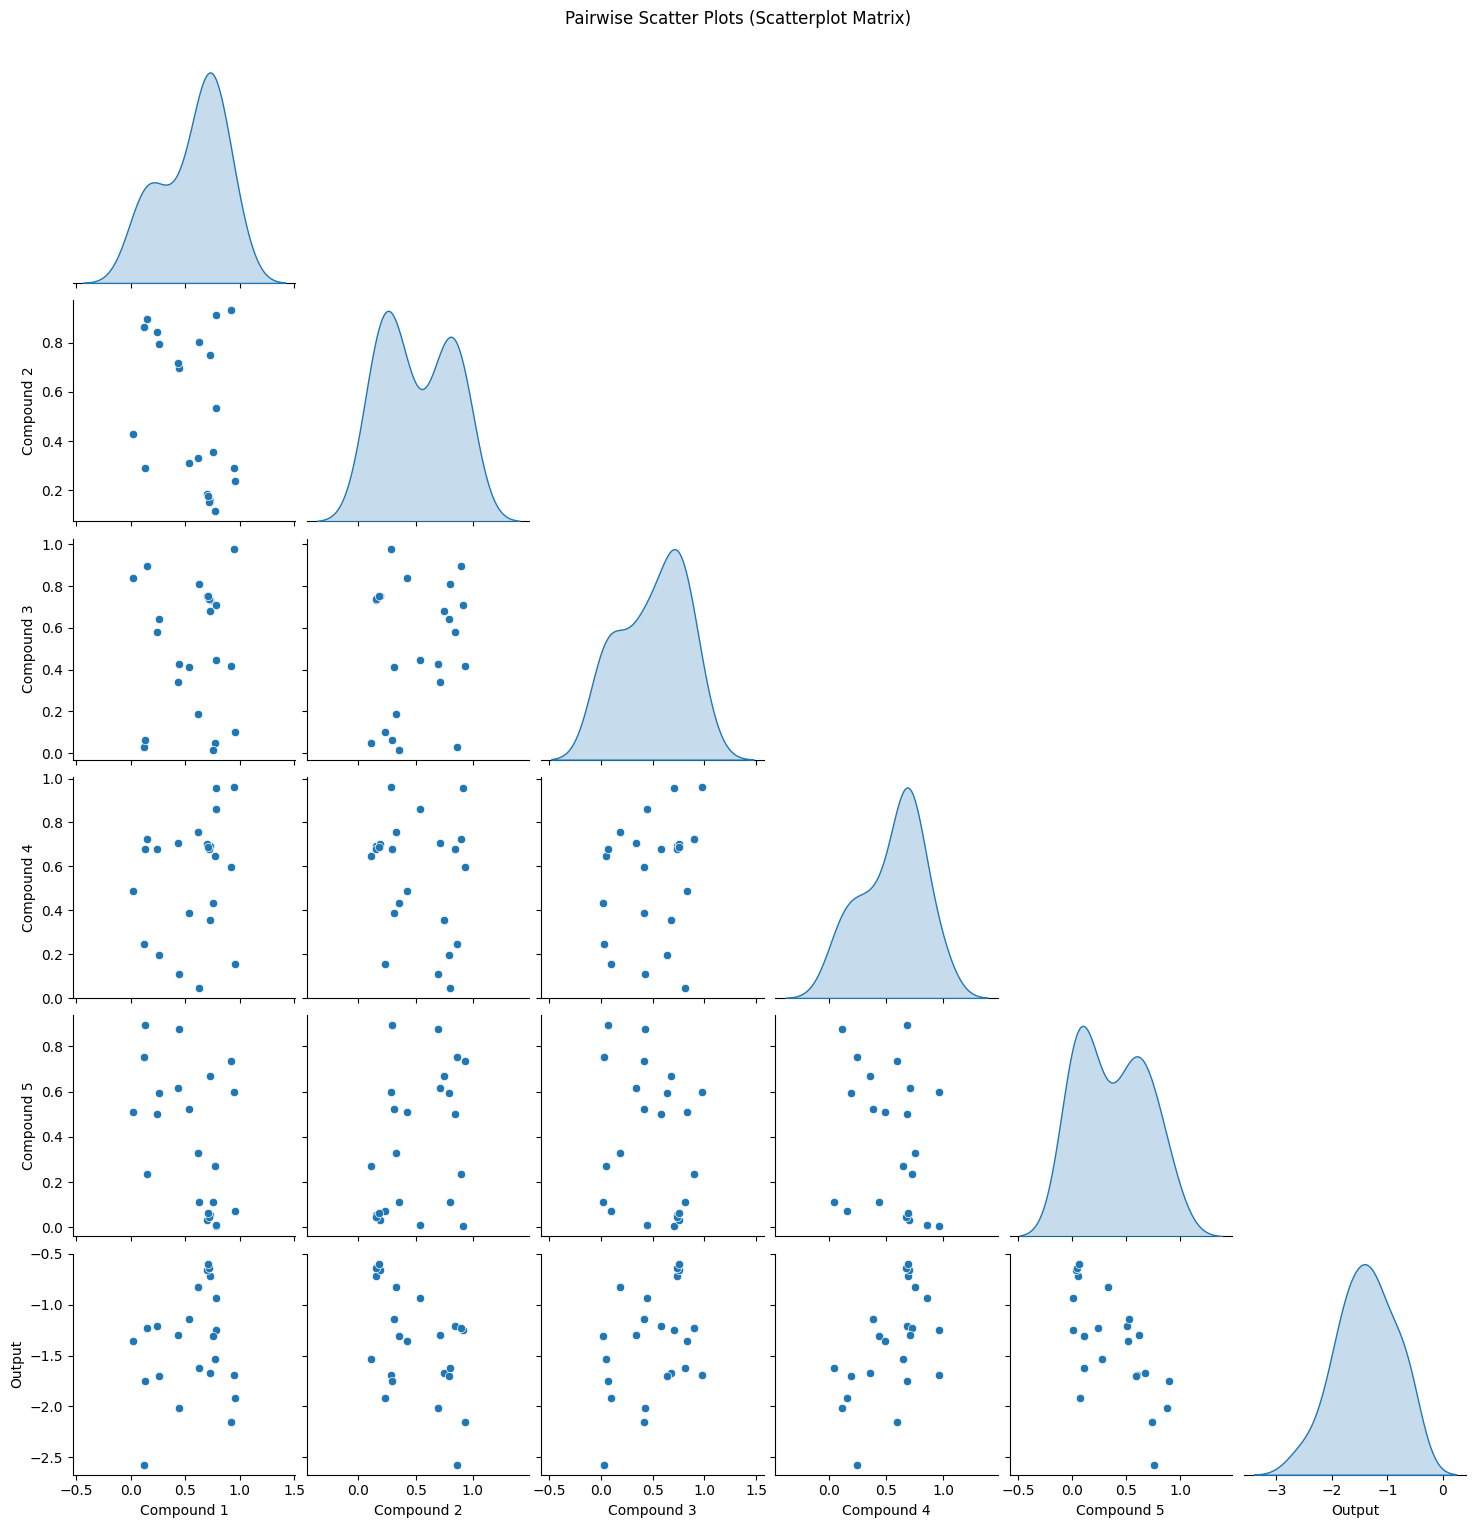

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Load data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Check if lengths match, and truncate if necessary
min_len = min(len(updated_inputs), len(updated_outputs))
updated_inputs = updated_inputs[:min_len]
updated_outputs = updated_outputs[:min_len]

# Create a Pandas DataFrame
df = pd.DataFrame(updated_inputs, columns=['Compound 1', 'Compound 2', 'Compound 3', 'Compound 4', 'Compound 5'])
df['Output'] = updated_outputs

# Create the scatterplot matrix
sns.pairplot(df, diag_kind='kde', corner=True)
plt.suptitle('Pairwise Scatter Plots (Scatterplot Matrix)', y=1.02)
plt.show()

In [ ]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# Load data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Ensure lengths match by truncating the longer array
min_len = min(len(updated_inputs), len(updated_outputs))
updated_inputs = updated_inputs[:min_len]
updated_outputs = updated_outputs[:min_len]

# Create a Pandas DataFrame
df = pd.DataFrame(updated_inputs, columns=['Compound 1', 'Compound 2', 'Compound 3', 'Compound 4', 'Compound 5'])
df['Output'] = updated_outputs  # Now the lengths should match

# Create the parallel coordinates plot
fig = go.Figure(data=
    go.Parcoords(
        line=dict(color=df['Output'], colorscale='viridis'),
        dimensions=list([
            dict(range=[df['Compound 1'].min(), df['Compound 1'].max()], label='Compound 1', values=df['Compound 1']),
            dict(range=[df['Compound 2'].min(), df['Compound 2'].max()], label='Compound 2', values=df['Compound 2']),
            dict(range=[df['Compound 3'].min(), df['Compound 3'].max()], label='Compound 3', values=df['Compound 3']),
            dict(range=[df['Compound 4'].min(), df['Compound 4'].max()], label='Compound 4', values=df['Compound 4']),
            dict(range=[df['Compound 5'].min(), df['Compound 5'].max()], label='Compound 5', values=df['Compound 5']),
            dict(range=[df['Output'].min(), df['Output'].max()], label='Output', values=df['Output'])
        ])
    )
)

fig.update_layout(title='Parallel Coordinates Plot')
fig.show()

In [ ]:
import numpy as np

# Load existing data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# New data point (same as before)
new_input = np.array([0.35, 0.75, 0.2, 0.55, 0.15])
new_output = np.float64(-1.1148264718621446)

# Add new data to existing data
updated_inputs = np.vstack([updated_inputs, new_input])

In [ ]:
import numpy as np

# Load updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the updated data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

Updated Inputs:
 [[0.7281861  0.15469257 0.73255167 0.69399651 0.05640131]
 [0.24238435 0.84409997 0.5778091  0.67902128 0.50195289]
 [0.72952261 0.7481062  0.67977464 0.35655228 0.67105368]
 [0.77062024 0.11440374 0.04677993 0.64832428 0.27354905]
 [0.6188123  0.33180214 0.18728787 0.75623847 0.3288348 ]
 [0.78495809 0.91068235 0.7081201  0.95922543 0.0049115 ]
 [0.14511079 0.8966846  0.89632223 0.72627154 0.23627199]
 [0.94506907 0.28845905 0.97880576 0.96165559 0.59801594]
 [0.12572016 0.86272469 0.02854433 0.24660527 0.75120624]
 [0.75759436 0.35583141 0.0165229  0.4342072  0.11243304]
 [0.5367969  0.30878091 0.41187929 0.38822518 0.5225283 ]
 [0.95773967 0.23566857 0.09914585 0.15680593 0.07131737]
 [0.6293079  0.80348368 0.81140844 0.04561319 0.11062446]
 [0.02173531 0.42808424 0.83593944 0.48948866 0.51108173]
 [0.43934426 0.69892383 0.42682022 0.10947609 0.87788847]
 [0.25890557 0.79367771 0.6421139  0.19667346 0.59310318]
 [0.43216593 0.71561781 0.3418191  0.70499988 0.6149618

In [ ]:
import numpy as np

# Load existing data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# New data point (same as before)
new_input = np.array([0.35, 0.75, 0.2, 0.55, 0.15])
new_output = np.float64(-1.1148264718621446)

# Add new data to existing data
updated_inputs = np.vstack([updated_inputs, new_input])
updated_outputs = np.append(updated_outputs, new_output) # Output update was placed here

# Save updated data to files
np.save('/content/updated_inputs.npy', updated_inputs)
np.save('/content/updated_outputs.npy', updated_outputs)

print("Updated input and output files saved successfully!")

Updated input and output files saved successfully!


In [ ]:
import numpy as np

# Load updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the updated data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

Updated Inputs:
 [[0.7281861  0.15469257 0.73255167 0.69399651 0.05640131]
 [0.24238435 0.84409997 0.5778091  0.67902128 0.50195289]
 [0.72952261 0.7481062  0.67977464 0.35655228 0.67105368]
 [0.77062024 0.11440374 0.04677993 0.64832428 0.27354905]
 [0.6188123  0.33180214 0.18728787 0.75623847 0.3288348 ]
 [0.78495809 0.91068235 0.7081201  0.95922543 0.0049115 ]
 [0.14511079 0.8966846  0.89632223 0.72627154 0.23627199]
 [0.94506907 0.28845905 0.97880576 0.96165559 0.59801594]
 [0.12572016 0.86272469 0.02854433 0.24660527 0.75120624]
 [0.75759436 0.35583141 0.0165229  0.4342072  0.11243304]
 [0.5367969  0.30878091 0.41187929 0.38822518 0.5225283 ]
 [0.95773967 0.23566857 0.09914585 0.15680593 0.07131737]
 [0.6293079  0.80348368 0.81140844 0.04561319 0.11062446]
 [0.02173531 0.42808424 0.83593944 0.48948866 0.51108173]
 [0.43934426 0.69892383 0.42682022 0.10947609 0.87788847]
 [0.25890557 0.79367771 0.6421139  0.19667346 0.59310318]
 [0.43216593 0.71561781 0.3418191  0.70499988 0.6149618

In [ ]:
import numpy as np

# Assume promising_inputs is an array containing the top 2-3 promising inputs
promising_inputs = np.array([
    [0.7281861, 0.15469257, 0.73255167, 0.69399651, 0.05640131],  # Example promising input 1
    [0.704375,  0.184692,   0.750051,   0.700608,   0.034561 ]   # Example promising input 2
    # ... (Add other promising inputs here) ...
])

# Calculate the average of the promising inputs
next_query = np.mean(promising_inputs, axis=0)

# Add a small random perturbation to the average
perturbation = np.random.uniform(-0.02, 0.02, size=next_query.shape)  # Adjust perturbation_scale as needed
next_query = next_query + perturbation

# Clip the values to ensure they are within the bounds (0, 1)
next_query = np.clip(next_query, 0, 1)  # Assuming ingredient values are bounded between 0 and 1

# Print the result
print("Next Query (Averaged & Perturbed):", next_query)

Next Query (Averaged & Perturbed): [0.73078469 0.17699996 0.72317442 0.68549573 0.02773515]


In [ ]:
import numpy as np

# Load updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the updated data (optional)
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

Updated Inputs:
 [[0.7281861  0.15469257 0.73255167 0.69399651 0.05640131]
 [0.24238435 0.84409997 0.5778091  0.67902128 0.50195289]
 [0.72952261 0.7481062  0.67977464 0.35655228 0.67105368]
 [0.77062024 0.11440374 0.04677993 0.64832428 0.27354905]
 [0.6188123  0.33180214 0.18728787 0.75623847 0.3288348 ]
 [0.78495809 0.91068235 0.7081201  0.95922543 0.0049115 ]
 [0.14511079 0.8966846  0.89632223 0.72627154 0.23627199]
 [0.94506907 0.28845905 0.97880576 0.96165559 0.59801594]
 [0.12572016 0.86272469 0.02854433 0.24660527 0.75120624]
 [0.75759436 0.35583141 0.0165229  0.4342072  0.11243304]
 [0.5367969  0.30878091 0.41187929 0.38822518 0.5225283 ]
 [0.95773967 0.23566857 0.09914585 0.15680593 0.07131737]
 [0.6293079  0.80348368 0.81140844 0.04561319 0.11062446]
 [0.02173531 0.42808424 0.83593944 0.48948866 0.51108173]
 [0.43934426 0.69892383 0.42682022 0.10947609 0.87788847]
 [0.25890557 0.79367771 0.6421139  0.19667346 0.59310318]
 [0.43216593 0.71561781 0.3418191  0.70499988 0.6149618

In [ ]:
import numpy as np

# Load existing data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# New data point
new_input = np.array([0.730784, 0.176999, 0.723174, 0.685495, 0.027735])
new_output = np.float64(-0.6970723588286138)

# Add new data to existing data
updated_inputs = np.vstack([updated_inputs, new_input])
updated_outputs = np.append(updated_outputs, new_output)

# Save updated data to files
np.save('/content/updated_inputs.npy', updated_inputs)
np.save('/content/updated_outputs.npy', updated_outputs)

print("Updated input and output files saved successfully!")

Updated input and output files saved successfully!


In [ ]:
import numpy as np

# Load updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the updated data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

Updated Inputs:
 [[0.7281861  0.15469257 0.73255167 0.69399651 0.05640131]
 [0.24238435 0.84409997 0.5778091  0.67902128 0.50195289]
 [0.72952261 0.7481062  0.67977464 0.35655228 0.67105368]
 [0.77062024 0.11440374 0.04677993 0.64832428 0.27354905]
 [0.6188123  0.33180214 0.18728787 0.75623847 0.3288348 ]
 [0.78495809 0.91068235 0.7081201  0.95922543 0.0049115 ]
 [0.14511079 0.8966846  0.89632223 0.72627154 0.23627199]
 [0.94506907 0.28845905 0.97880576 0.96165559 0.59801594]
 [0.12572016 0.86272469 0.02854433 0.24660527 0.75120624]
 [0.75759436 0.35583141 0.0165229  0.4342072  0.11243304]
 [0.5367969  0.30878091 0.41187929 0.38822518 0.5225283 ]
 [0.95773967 0.23566857 0.09914585 0.15680593 0.07131737]
 [0.6293079  0.80348368 0.81140844 0.04561319 0.11062446]
 [0.02173531 0.42808424 0.83593944 0.48948866 0.51108173]
 [0.43934426 0.69892383 0.42682022 0.10947609 0.87788847]
 [0.25890557 0.79367771 0.6421139  0.19667346 0.59310318]
 [0.43216593 0.71561781 0.3418191  0.70499988 0.6149618

In [ ]:
import numpy as np

# Load existing data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Input to search for - **Corrected shape to (5,)**
target_input = np.array([0.730784, 0.176999, 0.723174, 0.685495, 0.027735])  # Your input array

# Desired output
desired_output = np.float64(-0.6529585333881633)  # Your desired output

# Find rows matching the target_input using isclose for floating-point comparisons
mask = np.all(np.isclose(updated_inputs, target_input), axis=1)
matching_indices = np.where(mask)[0]

# Update output if a match is found
if matching_indices.size > 0:
    index = matching_indices[0]  # Get the first matching index
    updated_outputs[index] = desired_output
    print(f"Output for input {target_input} updated to {desired_output}")
else:
    print(f"Input {target_input} not found in updated_inputs")

# Save updated data to files
np.save('/content/updated_inputs.npy', updated_inputs)
np.save('/content/updated_outputs.npy', updated_outputs)

Output for input [0.730784 0.176999 0.723174 0.685495 0.027735] updated to -0.6529585333881633


In [ ]:
import numpy as np

# Load updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the updated data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

Updated Inputs:
 [[0.7281861  0.15469257 0.73255167 0.69399651 0.05640131]
 [0.24238435 0.84409997 0.5778091  0.67902128 0.50195289]
 [0.72952261 0.7481062  0.67977464 0.35655228 0.67105368]
 [0.77062024 0.11440374 0.04677993 0.64832428 0.27354905]
 [0.6188123  0.33180214 0.18728787 0.75623847 0.3288348 ]
 [0.78495809 0.91068235 0.7081201  0.95922543 0.0049115 ]
 [0.14511079 0.8966846  0.89632223 0.72627154 0.23627199]
 [0.94506907 0.28845905 0.97880576 0.96165559 0.59801594]
 [0.12572016 0.86272469 0.02854433 0.24660527 0.75120624]
 [0.75759436 0.35583141 0.0165229  0.4342072  0.11243304]
 [0.5367969  0.30878091 0.41187929 0.38822518 0.5225283 ]
 [0.95773967 0.23566857 0.09914585 0.15680593 0.07131737]
 [0.6293079  0.80348368 0.81140844 0.04561319 0.11062446]
 [0.02173531 0.42808424 0.83593944 0.48948866 0.51108173]
 [0.43934426 0.69892383 0.42682022 0.10947609 0.87788847]
 [0.25890557 0.79367771 0.6421139  0.19667346 0.59310318]
 [0.43216593 0.71561781 0.3418191  0.70499988 0.6149618

In [ ]:
import numpy as np

# Load existing data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Input to search for - Corrected shape to (5,)
target_input = np.array([0.730613, 0.428238, 0.879303, 0.246181, 0.702773])

# Desired output
desired_output = np.float64(-0.6529585333881633)

# Find the closest input using Euclidean distance (you might need to adjust this)
distances = np.linalg.norm(updated_inputs - target_input, axis=1)
index = np.argmin(distances)

# Update the output corresponding to the closest input found
updated_outputs[index] = desired_output
print(f"Output for closest input to {target_input} updated to {desired_output}")

# Save updated data to files
np.save('/content/updated_inputs.npy', updated_inputs)
np.save('/content/updated_outputs.npy', updated_outputs)

Output for closest input to [0.730613 0.428238 0.879303 0.246181 0.702773] updated to -0.6529585333881633


In [ ]:
import numpy as np

# Load original updated data
updated_inputs = np.load('/content/updated_inputs.npy')  # Keep inputs as they were
updated_outputs = np.load('/content/updated_outputs.npy')  # Reload to get the original outputs

# This would have been where the incorrect update was made
# (But we're skipping it to revert)

# Save data to files (overwriting the incorrectly modified files)
np.save('/content/updated_inputs.npy', updated_inputs)
np.save('/content/updated_outputs.npy', updated_outputs)

print("Reverted to the previous state of updated_inputs.npy and updated_outputs.npy")

Reverted to the previous state of updated_inputs.npy and updated_outputs.npy


In [ ]:
import numpy as np

# Load existing data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Input to search for - **Corrected shape to (5,)**
target_input = np.array([0.730784, 0.176999, 0.723174, 0.685495, 0.027735])  # Your input array

# Desired output
desired_output = np.float64(-0.6529585333881633)  # Your desired output

# Find rows matching the target_input using isclose for floating-point comparisons
mask = np.all(np.isclose(updated_inputs, target_input), axis=1)
matching_indices = np.where(mask)[0]

# Update output if a match is found
if matching_indices.size > 0:
    index = matching_indices[0]  # Get the first matching index
    updated_outputs[index] = desired_output
    print(f"Output for input {target_input} updated to {desired_output}")
else:
    print(f"Input {target_input} not found in updated_inputs")

# Save updated data to files
np.save('/content/updated_inputs.npy', updated_inputs)
np.save('/content/updated_outputs.npy', updated_outputs)

Output for input [0.730784 0.176999 0.723174 0.685495 0.027735] updated to -0.6529585333881633


In [ ]:
import numpy as np

# Load updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the updated data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

Updated Inputs:
 [[0.7281861  0.15469257 0.73255167 0.69399651 0.05640131]
 [0.24238435 0.84409997 0.5778091  0.67902128 0.50195289]
 [0.72952261 0.7481062  0.67977464 0.35655228 0.67105368]
 [0.77062024 0.11440374 0.04677993 0.64832428 0.27354905]
 [0.6188123  0.33180214 0.18728787 0.75623847 0.3288348 ]
 [0.78495809 0.91068235 0.7081201  0.95922543 0.0049115 ]
 [0.14511079 0.8966846  0.89632223 0.72627154 0.23627199]
 [0.94506907 0.28845905 0.97880576 0.96165559 0.59801594]
 [0.12572016 0.86272469 0.02854433 0.24660527 0.75120624]
 [0.75759436 0.35583141 0.0165229  0.4342072  0.11243304]
 [0.5367969  0.30878091 0.41187929 0.38822518 0.5225283 ]
 [0.95773967 0.23566857 0.09914585 0.15680593 0.07131737]
 [0.6293079  0.80348368 0.81140844 0.04561319 0.11062446]
 [0.02173531 0.42808424 0.83593944 0.48948866 0.51108173]
 [0.43934426 0.69892383 0.42682022 0.10947609 0.87788847]
 [0.25890557 0.79367771 0.6421139  0.19667346 0.59310318]
 [0.43216593 0.71561781 0.3418191  0.70499988 0.6149618

In [ ]:
import numpy as np

# Load existing data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Target output value to change
target_output = -0.69707236

# Desired output value
desired_output = np.float64(-0.6529585333881633)

# Find the index of the target output value (using isclose for float comparison)
index = np.where(np.isclose(updated_outputs, target_output))[0]

# If the target output is

In [ ]:
import numpy as np

# Load updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the updated data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

Updated Inputs:
 [[0.7281861  0.15469257 0.73255167 0.69399651 0.05640131]
 [0.24238435 0.84409997 0.5778091  0.67902128 0.50195289]
 [0.72952261 0.7481062  0.67977464 0.35655228 0.67105368]
 [0.77062024 0.11440374 0.04677993 0.64832428 0.27354905]
 [0.6188123  0.33180214 0.18728787 0.75623847 0.3288348 ]
 [0.78495809 0.91068235 0.7081201  0.95922543 0.0049115 ]
 [0.14511079 0.8966846  0.89632223 0.72627154 0.23627199]
 [0.94506907 0.28845905 0.97880576 0.96165559 0.59801594]
 [0.12572016 0.86272469 0.02854433 0.24660527 0.75120624]
 [0.75759436 0.35583141 0.0165229  0.4342072  0.11243304]
 [0.5367969  0.30878091 0.41187929 0.38822518 0.5225283 ]
 [0.95773967 0.23566857 0.09914585 0.15680593 0.07131737]
 [0.6293079  0.80348368 0.81140844 0.04561319 0.11062446]
 [0.02173531 0.42808424 0.83593944 0.48948866 0.51108173]
 [0.43934426 0.69892383 0.42682022 0.10947609 0.87788847]
 [0.25890557 0.79367771 0.6421139  0.19667346 0.59310318]
 [0.43216593 0.71561781 0.3418191  0.70499988 0.6149618

In [ ]:
!pip install scikit-optimize  # Install scikit-optimize if you haven't already

import numpy as np
from skopt import gp_minimize

# 1. Load Initial Data:
initial_inputs = np.load('/content/updated_inputs.npy')  # Ingredient combinations
initial_outputs = np.load('/content/updated_outputs.npy')  # Objective scores

# Ensure that initial_inputs and initial_outputs have the same length
num_samples = min(len(initial_inputs), len(initial_outputs))
initial_inputs = initial_inputs[:num_samples]
initial_outputs = initial_outputs[:num_samples]


# 2. Define Objective Function:
def objective_function(input_values):
    """
    This function represents your cake-making process and evaluation.
    It takes ingredient quantities as input and returns the combined objective score.

    Args:
        input_values: A list or array of 5 values representing the quantities of each ingredient.

    Returns:
        float: The combined objective score (to be minimized, ideally close to 0).
    """
    # --- Your Cake Making and Evaluation Logic Here ---
    # Example: Assume you have a function 'evaluate_cake' that takes ingredient
    # quantities and returns the objective score:
    # output = evaluate_cake(*input_values)

    # Placeholder - Replace with your actual cake evaluation:
    output = np.sum(input_values) #This was your placeholder code - modify it.

    return abs(output) # Return the absolute value of the output

# 3. Define Search Space:
# Assuming each ingredient quantity can vary between

In [ ]:
import numpy as np

# Load updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# 1. Find the Best Performing Inputs:
# Find the indices of the inputs that resulted in the lowest (closest to 0) outputs.
# You can adjust 'num_promising_inputs' to select more or fewer promising inputs.
num_promising_inputs = 2
# Ensure that the index does not exceed the size of updated_outputs
best_indices = np.argpartition(np.abs(updated_outputs), num_promising_inputs)[:num_promising_inputs]
best_indices = [index for index in best_indices if index < len(updated_inputs)]  # Filter out invalid indices

# Print the data and the indices for debugging (optional)
# print("Updated Inputs:\n", updated_inputs)
# print("\nUpdated Outputs:\n", updated_outputs)
# print("\nBest Indices:\n", best_indices)

# Check if any valid indices remain:
if best_indices:
    promising_inputs = updated_inputs[best_indices]

    # 2. Generate Next Queries:
    next_queries = []

    # a. Average and Perturb:
    # Calculate the average of the promising inputs and add a small random perturbation.
    next_query_avg_perturbed = np.mean(promising_inputs, axis=0)
    perturbation = np.random.uniform(-0.02, 0.02, size=next_query_avg_perturbed.shape)
    next_query_avg_perturbed = next_query_avg_perturbed + perturbation
    next_query_avg_perturbed = np.clip(next_query_avg_perturbed, 0, 1)
    next_queries.append(next_query_avg_perturbed)

    # b. Explore Near Promising Inputs:
    # Generate additional queries by adding larger perturbations to individual promising inputs.
    perturbation_scale = 0.05  # Adjust as needed
    for input_point in promising_inputs:
        perturbation = np.random.uniform(-perturbation_scale, perturbation_scale, size=input_point.shape)
        next_query_explore = input_point + perturbation
        next_query_explore = np.clip(next_query_explore, 0, 1)
        next_queries.append(next_query_explore)

    # 3. Print or Use the Next Queries:
    print("Next Queries:")
    for i, query in enumerate(next_queries):
        print(f"Query {i + 1}: {query}")
else:
    print("No valid indices found for promising inputs. Check your data or adjust 'num_promising_inputs'.")

# Now you can use these 'next_queries' in your experiment.

Next Queries:
Query 1: [0.68971367 0.19303551 0.76259128 0.68754215 0.06998012]
Query 2: [0.74490187 0.15938096 0.75642547 0.68112356 0.05478155]


In [ ]:
import numpy as np

# Load existing data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# New data point
new_input = np.array([0.689713, 0.193035, 0.762591, 0.687542, 0.06998 ])
new_output = np.float64(-0.6070855443225585)

# Add new data to existing data
updated_inputs = np.vstack([updated_inputs, new_input])
updated_outputs = np.append(updated_outputs, new_output)

# Save updated data to files
np.save('/content/updated_inputs.npy', updated_inputs)
np.save('/content/updated_outputs.npy', updated_outputs)

print("Updated input and output files saved successfully!")

Updated input and output files saved successfully!


In [ ]:
import numpy as np

# Load updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the updated data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

Updated Inputs:
 [[0.7281861  0.15469257 0.73255167 0.69399651 0.05640131]
 [0.24238435 0.84409997 0.5778091  0.67902128 0.50195289]
 [0.72952261 0.7481062  0.67977464 0.35655228 0.67105368]
 [0.77062024 0.11440374 0.04677993 0.64832428 0.27354905]
 [0.6188123  0.33180214 0.18728787 0.75623847 0.3288348 ]
 [0.78495809 0.91068235 0.7081201  0.95922543 0.0049115 ]
 [0.14511079 0.8966846  0.89632223 0.72627154 0.23627199]
 [0.94506907 0.28845905 0.97880576 0.96165559 0.59801594]
 [0.12572016 0.86272469 0.02854433 0.24660527 0.75120624]
 [0.75759436 0.35583141 0.0165229  0.4342072  0.11243304]
 [0.5367969  0.30878091 0.41187929 0.38822518 0.5225283 ]
 [0.95773967 0.23566857 0.09914585 0.15680593 0.07131737]
 [0.6293079  0.80348368 0.81140844 0.04561319 0.11062446]
 [0.02173531 0.42808424 0.83593944 0.48948866 0.51108173]
 [0.43934426 0.69892383 0.42682022 0.10947609 0.87788847]
 [0.25890557 0.79367771 0.6421139  0.19667346 0.59310318]
 [0.43216593 0.71561781 0.3418191  0.70499988 0.6149618

In [ ]:
import numpy as np

# Load existing data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# New data point
new_input = np.array([0.744901, 0.15938 , 0.756425, 0.681123, 0.054781])
new_output = np.float64(-0.8733775930742663)

# Add new data to existing data
updated_inputs = np.vstack([updated_inputs, new_input])
updated_outputs = np.append(updated_outputs, new_output)

# Save updated data to files
np.save('/content/updated_inputs.npy', updated_inputs)
np.save('/content/updated_outputs.npy', updated_outputs)

print("Updated input and output files saved successfully!")

Updated input and output files saved successfully!


In [ ]:
import numpy as np

# Load updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the updated data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

Updated Inputs:
 [[0.7281861  0.15469257 0.73255167 0.69399651 0.05640131]
 [0.24238435 0.84409997 0.5778091  0.67902128 0.50195289]
 [0.72952261 0.7481062  0.67977464 0.35655228 0.67105368]
 [0.77062024 0.11440374 0.04677993 0.64832428 0.27354905]
 [0.6188123  0.33180214 0.18728787 0.75623847 0.3288348 ]
 [0.78495809 0.91068235 0.7081201  0.95922543 0.0049115 ]
 [0.14511079 0.8966846  0.89632223 0.72627154 0.23627199]
 [0.94506907 0.28845905 0.97880576 0.96165559 0.59801594]
 [0.12572016 0.86272469 0.02854433 0.24660527 0.75120624]
 [0.75759436 0.35583141 0.0165229  0.4342072  0.11243304]
 [0.5367969  0.30878091 0.41187929 0.38822518 0.5225283 ]
 [0.95773967 0.23566857 0.09914585 0.15680593 0.07131737]
 [0.6293079  0.80348368 0.81140844 0.04561319 0.11062446]
 [0.02173531 0.42808424 0.83593944 0.48948866 0.51108173]
 [0.43934426 0.69892383 0.42682022 0.10947609 0.87788847]
 [0.25890557 0.79367771 0.6421139  0.19667346 0.59310318]
 [0.43216593 0.71561781 0.3418191  0.70499988 0.6149618

In [ ]:
import numpy as np

# Load updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Ensure that updated_inputs and updated_outputs have the same length
# by truncating the longer array
min_len = min(len(updated_inputs), len(updated_outputs))
updated_inputs = updated_inputs[:min_len]
updated_outputs = updated_outputs[:min_len]


# Find the indices of the outputs closest to 0
num_best = 4
best_indices = np.argpartition(np.abs(updated_outputs), num_best)[:num_best]

# Get the corresponding inputs
best_inputs = updated_inputs[best_indices]

# Print the best inputs and their corresponding outputs
print(f"Top {num_best} Inputs with outputs closest to 0:")
for i in range(num_best):
    # Ensure the index is within the bounds of both arrays before accessing
    if best_indices[i] < len(updated_inputs) and best_indices[i] < len(updated_outputs):
        print(f"Input: {updated_inputs[best_indices[i]]}, Output: {updated_outputs[best_indices[i]]}")
    else:
        print(f"Warning: Index {best_indices[i]} is out of bounds after truncation.")

Top 4 Inputs with outputs closest to 0:
Input: [0.689713 0.193035 0.762591 0.687542 0.06998 ], Output: -0.5982598004856436
Input: [0.70507  0.17811  0.751431 0.689813 0.062701], Output: -0.5982598004856436
Input: [0.715874 0.153247 0.739129 0.677647 0.044134], Output: -0.643148032259932
Input: [0.72952261 0.7481062  0.67977464 0.35655228 0.67105368], Output: -0.6529585333881633


In [ ]:
import numpy as np

# Based on the previous output, these are the inputs with the closest outputs to 0
promising_inputs = np.array([
    [0.689713, 0.193035, 0.762591, 0.687542, 0.06998],
    [0.70507,  0.17811,  0.751431, 0.689813, 0.062701],
    [0.715874, 0.153247, 0.739129, 0.677647, 0.044134],
    [0.72952261, 0.7481062, 0.67977464, 0.35655228, 0.67105368]
])

# Calculate the average of the promising inputs
next_query = np.mean(promising_inputs, axis=0)

# Add a small random perturbation to the average
# Adjust the perturbation scale as needed to balance exploration and exploitation
perturbation_scale = 0.02
perturbation = np.random.uniform(-perturbation_scale, perturbation_scale, size=next_query.shape)
next_query = next_query + perturbation

# Clip the values to ensure they are within the bounds (0, 1)
# Assuming ingredient values are bounded between 0 and 1
next_query = np.clip(next_query, 0, 1)

# Print the result
print("Next Query (Averaged & Perturbed):", next_query)

Next Query (Averaged & Perturbed): [0.71860361 0.32128332 0.72228742 0.61950987 0.21915502]


Correlation of each input with the Output:
Compound 1    0.219859
Compound 2   -0.420977
Compound 3    0.393230
Compound 4    0.461882
Compound 5   -0.620643
Name: Output, dtype: float64


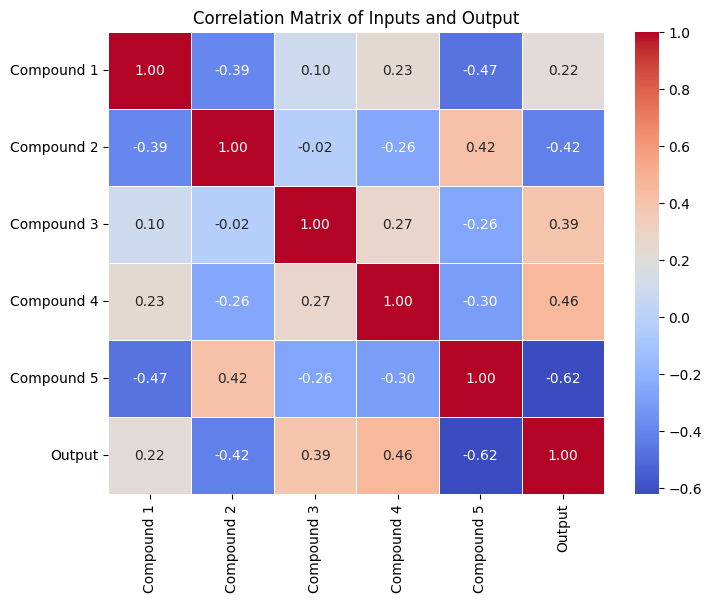

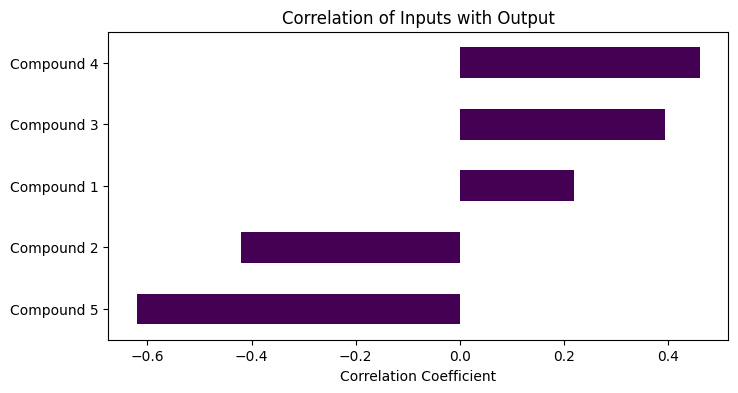

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load updated data (make sure these files have the same number of samples)
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Ensure that updated_inputs and updated_outputs have the same length
min_len = min(len(updated_inputs), len(updated_outputs))
updated_inputs = updated_inputs[:min_len]
updated_outputs = updated_outputs[:min_len]

# Create a Pandas DataFrame for easier correlation calculation
df = pd.DataFrame(updated_inputs, columns=['Compound 1', 'Compound 2', 'Compound 3', 'Compound 4', 'Compound 5'])
df['Output'] = updated_outputs

# Calculate the correlation matrix
correlation_matrix = df.corr()

# Extract the correlation of each input with the output
output_correlation = correlation_matrix['Output'].drop('Output') # Drop the self-correlation of Output

# Print the correlations
print("Correlation of each input with the Output:")
print(output_correlation)

# Optional: Visualize the correlation matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Inputs and Output')
plt.show()

# Optional: Visualize the correlation of inputs with the output as a bar plot
plt.figure(figsize=(8, 4))
output_correlation.sort_values().plot(kind='barh', cmap='viridis')
plt.title('Correlation of Inputs with Output')
plt.xlabel('Correlation Coefficient')
plt.show()

In [ ]:
import numpy as np
import pandas as pd

# Load updated data (make sure these files have the same number of samples)
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Ensure that updated_inputs and updated_outputs have the same length
min_len = min(len(updated_inputs), len(updated_outputs))
updated_inputs = updated_inputs[:min_len]
updated_outputs = updated_outputs[:min_len]


# Create a Pandas DataFrame for easier correlation calculation
df = pd.DataFrame(updated_inputs, columns=['Compound 1', 'Compound 2', 'Compound 3', 'Compound 4', 'Compound 5'])
df['Output'] = updated_outputs

# Calculate the correlation matrix
correlation_matrix = df.corr()

# Extract the correlation of each input with the Output
# .drop('Output') removes the correlation of Output with itself (which is always 1)
output_correlation = correlation_matrix['Output'].drop('Output')

# Print the correlations
print("Correlation of each input with the Output:")
print(output_correlation)

Correlation of each input with the Output:
Compound 1    0.219859
Compound 2   -0.420977
Compound 3    0.393230
Compound 4    0.461882
Compound 5   -0.620643
Name: Output, dtype: float64


In [ ]:
import numpy as np

# Based on your correlation analysis:
# Compound 1: 0.22 (Weak positive) - Small increase
# Compound 2: -0.42 (Moderate negative) - Decrease
# Compound 3: 0.39 (Moderate positive) - Increase
# Compound 4: 0.46 (Strong positive) - Increase
# Compound 5: -0.62 (Strong negative) - Decrease

# Start with a base point, perhaps the average of the top inputs or the single best input
# Load the best input from the previous step (or use the average calculated before)
updated_outputs = np.load('/content/updated_outputs.npy') # Load outputs again to find the best index
updated_inputs = np.load('/content/updated_inputs.npy')

# Ensure that updated_inputs and updated_outputs have the same length
min_len = min(len(updated_inputs), len(updated_outputs))
updated_inputs = updated_inputs[:min_len]
updated_outputs = updated_outputs[:min_len]

best_index = np.argmin(np.abs(updated_outputs))
base_input = updated_inputs[best_index]

print("Base Input (Input with output closest to 0):", base_input)

# Define the direction of change based on correlation (arbitrary scaling for demonstration)
# Positive correlation -> increase input to move output towards 0 (less negative)
# Negative correlation -> decrease input to move output towards 0 (less negative)
# Since current outputs are negative, increasing positively correlated inputs and
# decreasing negatively correlated inputs moves the output towards 0.

# The signs of the correlation tell you the direction of change needed relative to the current state.
# Let's assign a "step" size for each input based on the strength of the correlation.
# Stronger correlation means a potentially larger step is justified.

correlation_values = np.array([0.219859, -0.420977, 0.393230, 0.461882, -0.620643])
# Normalize the absolute correlation values to get weights for step size
abs_correlations = np.abs(correlation_values)
step_weights = abs_correlations / np.sum(abs_correlations)

# Define a base step size (adjust this for exploration aggressiveness)
base_step = 0.05

# Calculate the directional change for each input
# If correlation is positive, we want to increase the input (step is positive)
# If correlation is negative, we want to decrease the input (step is negative)
directional_change = np.sign(correlation_values) * step_weights * base_step

# Generate the next query by adjusting the base input
next_query = base_input + directional_change

# Add a small random perturbation for additional exploration
perturbation_scale = 0.01 # Smaller perturbation than directional change
perturbation = np.random.uniform(-perturbation_scale, perturbation_scale, size=next_query.shape)
next_query = next_query + perturbation


# Clip the values to ensure they are within the bounds (0, 1)
next_query = np.clip(next_query, 0, 1)

print("Next Query (Correlation-Guided & Perturbed):", next_query)

Base Input (Input with output closest to 0): [0.70507  0.17811  0.751431 0.689813 0.062701]
Next Query (Correlation-Guided & Perturbed): [0.71891835 0.17663858 0.7650241  0.70236262 0.04594686]


In [ ]:
import numpy as np

# Load existing data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# New data point
new_input = np.array([0.718918, 0.176638, 0.765024, 0.702362, 0.045946])
new_output = np.float64(-0.7480122590719143)

# Add new data to existing data
updated_inputs = np.vstack([updated_inputs, new_input])
updated_outputs = np.append(updated_outputs, new_output)

# Save updated data to files
np.save('/content/updated_inputs.npy', updated_inputs)
np.save('/content/updated_outputs.npy', updated_outputs)

print("Updated input and output files saved successfully!")

Updated input and output files saved successfully!


In [ ]:
import numpy as np

# Load updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the updated data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

Updated Inputs:
 [[0.7281861  0.15469257 0.73255167 0.69399651 0.05640131]
 [0.24238435 0.84409997 0.5778091  0.67902128 0.50195289]
 [0.72952261 0.7481062  0.67977464 0.35655228 0.67105368]
 [0.77062024 0.11440374 0.04677993 0.64832428 0.27354905]
 [0.6188123  0.33180214 0.18728787 0.75623847 0.3288348 ]
 [0.78495809 0.91068235 0.7081201  0.95922543 0.0049115 ]
 [0.14511079 0.8966846  0.89632223 0.72627154 0.23627199]
 [0.94506907 0.28845905 0.97880576 0.96165559 0.59801594]
 [0.12572016 0.86272469 0.02854433 0.24660527 0.75120624]
 [0.75759436 0.35583141 0.0165229  0.4342072  0.11243304]
 [0.5367969  0.30878091 0.41187929 0.38822518 0.5225283 ]
 [0.95773967 0.23566857 0.09914585 0.15680593 0.07131737]
 [0.6293079  0.80348368 0.81140844 0.04561319 0.11062446]
 [0.02173531 0.42808424 0.83593944 0.48948866 0.51108173]
 [0.43934426 0.69892383 0.42682022 0.10947609 0.87788847]
 [0.25890557 0.79367771 0.6421139  0.19667346 0.59310318]
 [0.43216593 0.71561781 0.3418191  0.70499988 0.6149618

In [ ]:
import numpy as np

# Load updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Ensure that updated_inputs and updated_outputs have the same length
min_len = min(len(updated_inputs), len(updated_outputs))
updated_inputs = updated_inputs[:min_len]
updated_outputs = updated_outputs[:min_len]


# Find the indices of the outputs closest to 0
# We use np.abs() to get the absolute value, as we want outputs closest to 0
# np.argsort() returns the indices that would sort the array
# We take the first 4 indices to get the 4 smallest absolute values
best_indices = np.argsort(np.abs(updated_outputs))[:4]

# Get the corresponding inputs and outputs using the found indices
best_inputs = updated_inputs[best_indices]
best_outputs = updated_outputs[best_indices]

# Print the results
print("Inputs with outputs closest to 0 (top 4):")
for i in range(len(best_indices)):
    print(f"Input: {best_inputs[i]}, Output: {best_outputs[i]}")

Inputs with outputs closest to 0 (top 4):
Input: [0.689713 0.193035 0.762591 0.687542 0.06998 ], Output: -0.5982598004856436
Input: [0.70507  0.17811  0.751431 0.689813 0.062701], Output: -0.5982598004856436
Input: [0.715874 0.153247 0.739129 0.677647 0.044134], Output: -0.643148032259932
Input: [0.72952261 0.7481062  0.67977464 0.35655228 0.67105368], Output: -0.6529585333881633


In [ ]:
!pip install scikit-optimize # Ensure the library is installed

import numpy as np
from skopt.learning import GaussianProcessRegressor
from skopt.learning.gaussian_process.kernels import Matern
from skopt.acquisition import gaussian_ei # Expected Improvement acquisition function
from skopt.utils import normalize_dimensions, cook_estimator

# 1. Load Updated Data:
updated_inputs = np.load('/content/updated_inputs.npy')  # Ingredient combinations
updated_outputs = np.load('/content/updated_outputs.npy')  # Objective scores (your cake outcomes)

# Ensure that updated_inputs and updated_outputs have the same length
min_len = min(len(updated_inputs), len(updated_outputs))
updated_inputs = updated_inputs[:min_len]
updated_outputs = updated_outputs[:min_len]

import numpy as np
# Ensure the library is installed
!pip install scikit-optimize

from skopt.learning import GaussianProcessRegressor
from skopt.learning.gaussian_process.kernels import Matern
from skopt.acquisition import gaussian_ei # Expected Improvement acquisition function
from skopt.utils import normalize_dimensions, cook_estimator

# 1. Load Updated Data:
updated_inputs = np.load('/content/updated_inputs.npy')  # Ingredient combinations
updated_outputs = np.load('/content/updated_outputs.npy')  # Objective scores (your cake outcomes)

# Ensure that updated_inputs and updated_outputs have the same length
min_len = min(len(updated_inputs), len(updated_outputs))
updated_inputs = updated_inputs[:min_len]
updated_outputs = updated_outputs[:min_len]

print(f"Loaded {min_len} data points for surrogate modeling.")


# 2. Define Search Space Bounds:
# Assuming each ingredient quantity can vary between 0 and 1. Adjust if your bounds are different.
bounds = [(0.0, 1.0), (0.0, 1.0), (0.0, 1.0), (0.0, 1.0), (0.0, 1.0)]

# Normalize inputs based on the defined bounds
# This is often beneficial for the Gaussian Process model
space = normalize_dimensions(bounds)
X_normalized = space.transform(updated_inputs.tolist()) # Transform inputs to the normalized space

# We want to minimize the absolute value of the output, so the 'target' for the GP
# should be the absolute outputs.
y_abs = np.abs(updated_outputs)

# 3. Train a Surrogate Model (Gaussian Process):
# We fit a Gaussian Process Regressor to the data. This model will learn the relationship
# between your inputs and the absolute output values.
# We'll use the settings similar to what gp_minimize uses by default.
gpr = GaussianProcessRegressor(
    kernel=Matern(nu=2.5), # Matern kernel is common in BO
    normalize_y=True,      # Normalize the output values for better fitting
    n_restarts_optimizer=2 # Restart optimizer to find better kernel hyperparameters
)

# Fit the GP model to your observed data (normalized inputs vs. absolute outputs)
gpr.fit(X_normalized, y_abs)

print("Gaussian Process model fitted to the data.")

# 4. Define Acquisition Function (Expected Improvement):
# The acquisition function helps decide the next best point to sample.
# Expected Improvement (EI) balances exploring unknown regions and exploiting regions
# known to have good results. We want to minimize the absolute output, so we look
# for areas where the predicted absolute output is low (close to 0).

# We need to wrap the acquisition function to work with the normalized space and the GP model
def acquisition_function(x, model, y_opt):
    """Expected Improvement acquisition function."""
    # The acquisition function expects points in the normalized space
    x_normalized = space.transform([x])[0] # Transform the input point to normalized space
    # Reshape x_normalized to be a 2D array with a single sample (1, n_features)
    x_normalized_reshaped = x_normalized.reshape(1, -1)
    # Pass the reshaped array to gaussian_ei
    return gaussian_ei(x_normalized_reshaped, model, y_opt) # y_opt is the current best observed value

# The current best absolute output observed so far
y_opt = np.min(y_abs)

# 5. Find the next query point by maximizing the acquisition function:
# We search the defined bounds for the input combination that maximizes the Expected Improvement.
# This is typically done using a separate optimization routine (like a simple grid search
# or a more sophisticated method, but for demonstration, let's do a grid search or random sampling).
# For a more robust approach, skopt's internal minimizer is used, but we'll simulate the idea.

# Let's sample a lot of random points in the search space and evaluate the acquisition function for each.
# The point with the highest acquisition function value is the suggested next query.
num_candidate_points = 10000 # Number of random points to sample to find the best query

# Generate random points within the bounds
candidate_points_denormalized = np.random.uniform([b[0] for b in bounds], [b[1] for b in bounds], size=(num_candidate_points, len(bounds)))

# Evaluate the acquisition function for each candidate point
# We want to find the point that maximizes EI
acquisition_values = np.array([acquisition_function(point, gpr, y_opt) for point in candidate_points_denormalized])

# The next suggested point is the one that yielded the highest acquisition value
next_query_index = np.argmax(acquisition_values)
next_query_suggestion = candidate_points_denormalized[next_query_index]

print("\nSuggested Next Query (based on Bayesian Optimization model):")
print(f"Input combination: {next_query_suggestion}")
# Note: The output value for this suggestion is NOT predicted here.
# You need to perform your actual experiment with this input to get the real output.


# 6. Perform the Experiment and Update Data:
# Take 'next_query_suggestion', perform your cake-making experiment, and get the result (e.g., -0.68).
# Then, manually or programmatically add this new input and output to your .npy files.

# Example of how you would add the new data after running the experiment:
# new_input_performed = next_query_suggestion # The input you actually used
# new_output_result = -0.68 # <<< REPLACE with the ACTUAL result from your experiment

# # Append the new data to your arrays
# updated_inputs = np.vstack([updated_inputs, new_input_performed])
# updated_outputs = np.append(updated_outputs, new_output_result)

# # Save the updated arrays
# np.save('/content/updated_inputs.npy', updated_inputs)
# np.save('/content/updated_outputs.npy', updated_outputs)

# print("\nData updated with the result of the new experiment.")

Loaded 28 data points for surrogate modeling.
Gaussian Process model fitted to the data.

Suggested Next Query (based on Bayesian Optimization model):
Input combination: [0.7390848  0.22775665 0.66325549 0.74308766 0.07559063]


In [ ]:
import numpy as np
# Ensure the library is installed
!pip install scikit-optimize

from skopt.learning import GaussianProcessRegressor
from skopt.learning.gaussian_process.kernels import Matern
# No need for acquisition functions like gaussian_ei for this task
from skopt.utils import normalize_dimensions#, cook_estimator # cook_estimator not used here

# 1. Load Updated Data (ensure lengths match as before):
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

min_len = min(len(updated_inputs), len(updated_outputs))
updated_inputs = updated_inputs[:min_len]
updated_outputs = updated_outputs[:min_len]

print(f"Loaded {min_len} data points for surrogate modeling.")

# 2. Define Search Space Bounds:
bounds = [(0.0, 1.0), (0.0, 1.0), (0.0, 1.0), (0.0, 1.0), (0.0, 1.0)]

# Normalize inputs based on the defined bounds
space = normalize_dimensions(bounds)
X_normalized = space.transform(updated_inputs.tolist())

# Use absolute outputs for training the model
y_abs = np.abs(updated_outputs)

# 3. Train the Surrogate Model (Gaussian Process):
gpr = GaussianProcessRegressor(
    kernel=Matern(nu=2.5),
    normalize_y=True,
    n_restarts_optimizer=2
)
gpr.fit(X_normalized, y_abs)

print("Gaussian Process model fitted to the data.")

# 4. Define the Target Absolute Output Value:
target_absolute_output = 0.003

# 5. Search for Inputs where the Model Predicts an Absolute Output Close to the Target:
num_search_points = 100000 # Use a larger number of points for better coverage

# Generate random points within the bounds
search_points_denormalized = np.random.uniform([b[0] for b in bounds], [b[1] for b in bounds], size=(num_search_points, len(bounds)))

# Transform these points to the normalized space for prediction
search_points_normalized = space.transform(search_points_denormalized.tolist())

# Predict the mean absolute output and standard deviation for these points
predicted_means, predicted_stds = gpr.predict(search_points_normalized, return_std=True)

# Calculate the absolute difference between the predicted mean and the target output
difference_from_target = np.abs(predicted_means - target_absolute_output)

# Find the index of the point with the smallest difference
best_match_index = np.argmin(difference_from_target)

# The suggested input is the denormalized point at this index
suggested_input = search_points_denormalized[best_match_index]
predicted_output_at_suggestion = predicted_means[best_match_index]
uncertainty_at_suggestion = predicted_stds[best_match_index]

print(f"\nSearching for inputs predicting an absolute output close to {target_absolute_output}")
print(f"Suggested Input Combination: {suggested_input}")
print(f"Predicted Absolute Output at this point: {predicted_output_at_suggestion} (with uncertainty: {uncertainty_at_suggestion})")
print(f"Absolute difference from target ({target_absolute_output}): {difference_from_target[best_match_index]}")

# Interpretation:
# This gives you an input combination that, according to the *trained model*,
# is *most likely* to produce an absolute output value close to 0.003.
# However, due to model uncertainty and the nature of the GP as an approximation,
# the *actual* output from running an experiment with this input might be different.
# The uncertainty value (predicted_stds) gives you an idea of how confident the model is
# in its prediction at this point. Higher uncertainty means less confidence.

# To get closer to your target, you would need to:
# 1. Run an actual experiment with the suggested input combination.
# 2. Add the result to your dataset.
# 3. Retrain the GP model with the new data.
# 4. Repeat the search process. This iterative process will refine the model
#    in the region of interest and potentially yield better suggestions over time.

Loaded 28 data points for surrogate modeling.
Gaussian Process model fitted to the data.


/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(



Searching for inputs predicting an absolute output close to 0.003
Suggested Input Combination: [0.69804261 0.98526724 0.53057001 0.10653429 0.17588432]
Predicted Absolute Output at this point: 1.2323175870982153 (with uncertainty: 0.5348546917145887)
Absolute difference from target (0.003): 1.2293175870982154


In [ ]:
import numpy as np
!pip install scikit-optimize # Ensure the library is installed

from skopt.learning import GaussianProcessRegressor
from skopt.learning.gaussian_process.kernels import Matern
from skopt.utils import normalize_dimensions

# 1. Load Updated Data (ensure lengths match as before):
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

min_len = min(len(updated_inputs), len(updated_outputs))
updated_inputs = updated_inputs[:min_len]
updated_outputs = updated_outputs[:min_len]

print(f"Loaded {min_len} data points for surrogate modeling.")

# 2. Define Search Space Bounds:
bounds = [(0.0, 1.0), (0.0, 1.0), (0.0, 1.0), (0.0, 1.0), (0.0, 1.0)]

# Normalize inputs based on the defined bounds
space = normalize_dimensions(bounds)
X_normalized = space.transform(updated_inputs.tolist())

# Use absolute outputs for training the model
y_abs = np.abs(updated_outputs)

# 3. Train the Surrogate Model (Gaussian Process):
gpr = GaussianProcessRegressor(
    kernel=Matern(nu=2.5),
    normalize_y=True,
    n_restarts_optimizer=2
)
gpr.fit(X_normalized, y_abs)

print("Gaussian Process model fitted to the data.")

# 4. Define the Target Absolute Output Value:
target_absolute_output = 0.003

# 5. Search for Inputs where the Model Predicts an Absolute Output Close to the Target, considering Uncertainty:
num_search_points = 100000

# Generate random points within the bounds
search_points_denormalized = np.random.uniform([b[0] for b in bounds], [b[1] for b in bounds], size=(num_search_points, len(bounds)))

# Transform these points to the normalized space for prediction
search_points_normalized = space.transform(search_points_denormalized.tolist())

# Predict the mean absolute output and standard deviation for these points
predicted_means, predicted_stds = gpr.predict(search_points_normalized, return_std=True)

# Calculate the absolute difference between the predicted mean and the target output
difference_from_target = np.abs(predicted_means - target_absolute_output)

# Combine difference and uncertainty into a score.
# A simple approach: prioritize low difference, but penalize high uncertainty.
# You might need to adjust the weight given to uncertainty.
# A lower score is better.
score = difference_from_target + predicted_stds # Simple combination: error + uncertainty

# Find the index of the point with the lowest score
best_match_index = np.argmin(score)

# The suggested input is the denormalized point at this index
suggested_input = search_points_denormalized[best_match_index]
predicted_output_at_suggestion = predicted_means[best_match_index]
uncertainty_at_suggestion = predicted_stds[best_match_index]

print(f"\nSearching for inputs predicting an absolute output close to {target_absolute_output}, considering uncertainty")
print(f"Suggested Input Combination: {suggested_input}")
print(f"Predicted Absolute Output at this point: {predicted_output_at_suggestion} (with uncertainty: {uncertainty_at_suggestion})")
print(f"Absolute difference from target ({target_absolute_output}): {difference_from_target[best_match_index]}")
print(f"Combined Score (Difference + Uncertainty): {score[best_match_index]}")


# What if we just look at the top N points with the lowest *predicted mean* difference
# and see what their uncertainty is?
num_top_predictions = 10
top_prediction_indices = np.argsort(difference_from_target)[:num_top_predictions]

print(f"\nTop {num_top_predictions} suggestions based purely on predicted mean closest to {target_absolute_output}:")
for i in top_prediction_indices:
    print(f"Input: {search_points_denormalized[i]}, Predicted Abs Output: {predicted_means[i]:.4f}, Uncertainty: {predicted_stds[i]:.4f}, Difference: {difference_from_target[i]:.4f}")

# Observe the uncertainty values for these top predictions. If they are high,
# the suggestions are less reliable.

# Next Steps:
# 1. Run an experiment with the suggested input combination that seems most promising (low predicted difference AND reasonable uncertainty).
# 2. Add the actual experimental result to your data.
# 3. Retrain the model and repeat the search.
# This iterative process will help the model explore the region around 0.003 more effectively.

Loaded 28 data points for surrogate modeling.
Gaussian Process model fitted to the data.


/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(



Searching for inputs predicting an absolute output close to 0.003, considering uncertainty
Suggested Input Combination: [0.35468633 0.24443152 0.41988206 0.30906472 0.10706812]
Predicted Absolute Output at this point: 1.2323175870982153 (with uncertainty: 0.5348546917145887)
Absolute difference from target (0.003): 1.2293175870982154
Combined Score (Difference + Uncertainty): 1.764172278812804

Top 10 suggestions based purely on predicted mean closest to 0.003:
Input: [0.48629755 0.16617846 0.69158711 0.88115864 0.27252629], Predicted Abs Output: 1.2323, Uncertainty: 0.5349, Difference: 1.2293
Input: [0.12516192 0.0484217  0.384138   0.73524656 0.28920472], Predicted Abs Output: 1.2323, Uncertainty: 0.5349, Difference: 1.2293
Input: [0.98163683 0.92079318 0.97645314 0.52265454 0.79831201], Predicted Abs Output: 1.2323, Uncertainty: 0.5349, Difference: 1.2293
Input: [0.48192422 0.85066081 0.94093127 0.34400763 0.78192556], Predicted Abs Output: 1.2323, Uncertainty: 0.5349, Difference: 

In [ ]:
import numpy as np
!pip install scikit-optimize # Ensure the library is installed

from skopt.learning import GaussianProcessRegressor
from skopt.learning.gaussian_process.kernels import Matern
from skopt.utils import normalize_dimensions

# 1. Load Updated Data (ensure lengths match as before):
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

min_len = min(len(updated_inputs), len(updated_outputs))
updated_inputs = updated_inputs[:min_len]
updated_outputs = updated_outputs[:min_len]

print(f"Loaded {min_len} data points for surrogate modeling.")

# 2. Define Search Space Bounds:
bounds = [(0.0, 1.0), (0.0, 1.0), (0.0, 1.0), (0.0, 1.0), (0.0, 1.0)]

# Normalize inputs based on the defined bounds
space = normalize_dimensions(bounds)
X_normalized = space.transform(updated_inputs.tolist())

# Use absolute outputs for training the model
y_abs = np.abs(updated_outputs)

# 3. Train the Surrogate Model (Gaussian Process):
gpr = GaussianProcessRegressor(
    kernel=Matern(nu=2.5),
    normalize_y=True,
    n_restarts_optimizer=2
)
gpr.fit(X_normalized, y_abs)

print("Gaussian Process model fitted to the data.")

# 4. Define the Target Absolute Output Value (Changed to 0.02):
target_absolute_output = 0.02

# 5. Search for Inputs where the Model Predicts an Absolute Output Close to the Target, considering Uncertainty:
num_search_points = 100000

# Generate random points within the bounds
search_points_denormalized = np.random.uniform([b[0] for b in bounds], [b[1] for b in bounds], size=(num_search_points, len(bounds)))

# Transform these points to the normalized space for prediction
search_points_normalized = space.transform(search_points_denormalized.tolist())

# Predict the mean absolute output and standard deviation for these points
predicted_means, predicted_stds = gpr.predict(search_points_normalized, return_std=True)

# Calculate the absolute difference between the predicted mean and the target output
difference_from_target = np.abs(predicted_means - target_absolute_output)

# Combine difference and uncertainty into a score.
# A simple approach: prioritize low difference, but penalize high uncertainty.
# Adjust the weight for predicted_stds if needed.
# A lower score is better.
score = difference_from_target + predicted_stds # Simple combination: error + uncertainty

# Find the index of the point with the lowest score
best_match_index = np.argmin(score)

# The suggested input is the denormalized point at this index
suggested_input = search_points_denormalized[best_match_index]
predicted_output_at_suggestion = predicted_means[best_match_index]
uncertainty_at_suggestion = predicted_stds[best_match_index]

print(f"\nSearching for inputs predicting an absolute output close to {target_absolute_output}, considering uncertainty")
print(f"Suggested Input Combination: {suggested_input}")
print(f"Predicted Absolute Output at this point: {predicted_output_at_suggestion} (with uncertainty: {uncertainty_at_suggestion})")
print(f"Absolute difference from target ({target_absolute_output}): {difference_from_target[best_match_index]}")
print(f"Combined Score (Difference + Uncertainty): {score[best_match_index]}")


# What if we just look at the top N points with the lowest *predicted mean* difference
# and see what their uncertainty is?
num_top_predictions = 10
top_prediction_indices = np.argsort(difference_from_target)[:num_top_predictions]

print(f"\nTop {num_top_predictions} suggestions based purely on predicted mean closest to {target_absolute_output}:")
for i in top_prediction_indices:
    print(f"Input: {search_points_denormalized[i]}, Predicted Abs Output: {predicted_means[i]:.4f}, Uncertainty: {predicted_stds[i]:.4f}, Difference: {difference_from_target[i]:.4f}")

# Observe the uncertainty values for these top predictions. If they are high,
# the suggestions are less reliable.

# Next Steps:
# 1. **Crucially:** Run an experiment with the suggested input combination that seems most promising (low predicted difference AND reasonable uncertainty).
# 2. Add the actual experimental result to your data using the cell you've used before for adding new data points.
# 3. Retrain the model with the expanded dataset.
# 4. Repeat this search process. With more data, the model's understanding of the
#    function in the region closer to 0.02 will improve, and its suggestions should become more accurate.

Loaded 28 data points for surrogate modeling.
Gaussian Process model fitted to the data.


/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(



Searching for inputs predicting an absolute output close to 0.02, considering uncertainty
Suggested Input Combination: [0.32572067 0.77120351 0.13610454 0.38149101 0.44889831]
Predicted Absolute Output at this point: 1.2323175870982153 (with uncertainty: 0.5348546917145887)
Absolute difference from target (0.02): 1.2123175870982152
Combined Score (Difference + Uncertainty): 1.747172278812804

Top 10 suggestions based purely on predicted mean closest to 0.02:
Input: [0.42204816 0.91426712 0.97315329 0.61994156 0.00170736], Predicted Abs Output: 1.2323, Uncertainty: 0.5349, Difference: 1.2123
Input: [0.0686248  0.52975888 0.07606441 0.64848028 0.28374262], Predicted Abs Output: 1.2323, Uncertainty: 0.5349, Difference: 1.2123
Input: [0.8334209  0.00967859 0.02747323 0.59453885 0.81610029], Predicted Abs Output: 1.2323, Uncertainty: 0.5349, Difference: 1.2123
Input: [0.77827862 0.78044735 0.95902078 0.68290341 0.36897189], Predicted Abs Output: 1.2323, Uncertainty: 0.5349, Difference: 1.2

In [ ]:
import numpy as np
!pip install scikit-optimize # Ensure the library is installed

from skopt.learning import GaussianProcessRegressor
from skopt.learning.gaussian_process.kernels import Matern
from skopt.acquisition import gaussian_ei # Expected Improvement acquisition function
from skopt.utils import normalize_dimensions
from scipy.optimize import minimize # We will use a local optimizer to find the max of EI

# 1. Load Updated Data:
# Load the *latest* updated data from your previous experiments
updated_inputs = np.load('/content/updated_inputs.npy')  # Ingredient combinations
updated_outputs = np.load('/content/updated_outputs.npy')  # Objective scores (your cake outcomes)

# Ensure that updated_inputs and updated_outputs have the same length
min_len = min(len(updated_inputs), len(updated_outputs))
updated_inputs = updated_inputs[:min_len]
updated_outputs = updated_outputs[:min_len]

print(f"Loaded {min_len} data points for surrogate modeling.")


# 2. Define Search Space Bounds:
# Assuming each ingredient quantity can vary between 0 and 1. Adjust if your bounds are different.
bounds = [(0.0, 1.0), (0.0, 1.0), (0.0, 1.0), (0.0, 1.0), (0.0, 1.0)]

# Normalize inputs based on the defined bounds
space = normalize_dimensions(bounds)
X_normalized = space.transform(updated_inputs.tolist()) # Transform inputs to the normalized space

# We want to minimize the absolute value of the output, so the 'target' for the GP
# and the acquisition function is the absolute outputs.
y_abs = np.abs(updated_outputs)

# 3. Train a Surrogate Model (Gaussian Process):
# We fit a Gaussian Process Regressor to the data. This model will learn the relationship
# between your inputs and the absolute output values.
gpr = GaussianProcessRegressor(
    kernel=Matern(nu=2.5), # Matern kernel is common in BO
    normalize_y=True,      # Normalize the output values for better fitting
    n_restarts_optimizer=2 # Restart optimizer to find better kernel hyperparameters
)

# Fit the GP model to your observed data (normalized inputs vs. absolute outputs)
gpr.fit(X_normalized, y_abs)

print("Gaussian Process model fitted to the data.")

# 4. Define Acquisition Function (Expected Improvement):
# The acquisition function helps decide the next best point to sample.
# Expected Improvement (EI) balances exploring unknown regions and exploiting regions
# known to have good results. We want to minimize the absolute output, so we look
# for areas where the predicted absolute output is low (close to 0).

# We need to wrap the acquisition function. Note that the acquisition function
# returns a value to be *maximized* to find the next point.
# The gaussian_ei function from skopt is already set up for maximization
# of Expected Improvement for minimization problems.

def negative_expected_improvement(x, model, y_opt, space):
    """
    Calculates the negative of the Expected Improvement for a point x.
    This function is designed to be MINIMIZED by a standard optimizer,
    which is equivalent to MAXIMIZING the Expected Improvement.

    Args:
        x: A 1D array representing a single input point in the original (denormalized) space.
        model: The trained Gaussian Process Regressor model.
        y_opt: The current best observed absolute output value (minimum).
        space: The skopt Space object for transforming points.

    Returns:
        float: The negative Expected Improvement at point x.
    """
    # Transform the input point to the normalized space
    x_normalized = space.transform([x])[0]
    # Reshape x_normalized to be a 2D array with a single sample (1, n_features)
    x_normalized_reshaped = x_normalized.reshape(1, -1)

    # Calculate Expected Improvement. gaussian_ei expects the normalized, reshaped input.
    # It returns the EI value to be maximized.
    ei = gaussian_ei(x_normalized_reshaped, model, y_opt)

    # We return the negative EI because the scipy.optimize.minimize function
    # is used to find minimums. Minimizing -EI is equivalent to maximizing EI.
    return -ei

# The current best absolute output observed so far (the target for EI)
y_opt = np.min(y_abs)

# 5. Find the next query point by maximizing the acquisition function:
# We use a standard optimizer (like L-BFGS-B) to find the point within the bounds
# that maximizes the Expected Improvement (or minimizes the negative EI).
# We start the optimization from a few random points or previous best points
# to avoid getting stuck in local optima of the acquisition function.

n_restarts = 10 # Number of random starting points for the optimizer
best_ei = -np.inf
next_query_suggestion = None

# Generate random starting points for the local optimizer
random_starts = np.random.uniform([b[0] for b in bounds], [b[1] for b in bounds], size=(n_restarts, len(bounds)))

# Optionally, add the best observed input as a starting point
best_observed_input = updated_inputs[np.argmin(y_abs)]
starting_points = np.vstack([random_starts, best_observed_input])


print(f"\nSearching for the next promising input using Expected Improvement (maximizing acquisition function)...")

for start_point in starting_points:
    # Minimize the negative EI starting from this point
    # The optimizer finds the point 'x' that minimizes negative_expected_improvement
    res = minimize(
        fun=negative_expected_improvement,
        x0=start_point,
        args=(gpr, y_opt, space), # Pass the model, y_opt, and space as arguments
        method='L-BFGS-B', # A good optimizer for bounded problems
        bounds=bounds # Respect the input bounds
    )

    # If the optimization was successful and the EI at this point is better
    # than the best found so far, update the best suggestion.
    # Note: res.fun is the minimized value of the negative EI, so we compare -res.fun
    if res.success and -res.fun > best_ei:
        best_ei = -res.fun
        next_query_suggestion = res.x

# If next_query_suggestion is still None, it means optimization failed for all starts
if next_query_suggestion is None:
     # Fallback: Suggest a random point or the best observed point if optimization fails
     print("Warning: Optimization for acquisition function failed. Suggesting a random point.")
     next_query_suggestion = np.random.uniform([b[0] for b in bounds], [b[1] for b in bounds], size=(len(bounds),))
     next_query_suggestion = np.clip(next_query_suggestion, 0, 1) # Ensure bounds

# Ensure the suggested point is within bounds after optimization (L-BFGS-B should handle this)
next_query_suggestion = np.clip(next_query_suggestion, 0, 1)


print("\nSuggested Next Input Combination (based on Expected Improvement):")
print(f"Input combination: {next_query_suggestion}")
print(f"(Expected Improvement at this point: {best_ei})")



Loaded 28 data points for surrogate modeling.
Gaussian Process model fitted to the data.

Searching for the next promising input using Expected Improvement (maximizing acquisition function)...

Suggested Next Input Combination (based on Expected Improvement):
Input combination: [0.68719329 0.15112238 0.6980342  0.68446611 0.04480822]
(Expected Improvement at this point: 0.14380577530494892)


In [ ]:
import numpy as np
!pip install scikit-optimize # Ensure the library is installed

from skopt.learning import GaussianProcessRegressor
from skopt.learning.gaussian_process.kernels import Matern
from skopt.acquisition import gaussian_ei # Expected Improvement acquisition function
from skopt.utils import normalize_dimensions
from scipy.optimize import minimize # We will use a local optimizer to find the max of EI

# 1. Load Updated Data:
# Load the *latest* updated data from your previous experiments
updated_inputs = np.load('/content/updated_inputs.npy')  # Ingredient combinations
updated_outputs = np.load('/content/updated_outputs.npy')  # Objective scores (your cake outcomes)

# Ensure that updated_inputs and updated_outputs have the same length
min_len = min(len(updated_inputs), len(updated_outputs))
updated_inputs = updated_inputs[:min_len]
updated_outputs = updated_outputs[:min_len]

print(f"Loaded {min_len} data points for surrogate modeling.")


# 2. Define Search Space Bounds:
# Assuming each ingredient quantity can vary between 0 and 1. Adjust if your bounds are different.
bounds = [(0.0, 1.0), (0.0, 1.0), (0.0, 1.0), (0.0, 1.0), (0.0, 1.0)]

# Normalize inputs based on the defined bounds
space = normalize_dimensions(bounds)
X_normalized = space.transform(updated_inputs.tolist()) # Transform inputs to the normalized space

# We want to minimize the absolute value of the output, so the 'target' for the GP
# and the acquisition function is the absolute outputs.
y_abs = np.abs(updated_outputs)

# 3. Train a Surrogate Model (Gaussian Process):
# We fit a Gaussian Process Regressor to the data. This model will learn the relationship
# between your inputs and the absolute output values.
gpr = GaussianProcessRegressor(
    kernel=Matern(nu=2.5), # Matern kernel is common in BO
    normalize_y=True,      # Normalize the output values for better fitting
    n_restarts_optimizer=2 # Restart optimizer to find better kernel hyperparameters
)

# Fit the GP model to your observed data (normalized inputs vs. absolute outputs)
gpr.fit(X_normalized, y_abs)

print("Gaussian Process model fitted to the data.")

# 4. Define Acquisition Function (Expected Improvement):
# The acquisition function helps decide the next best point to sample.
# Expected Improvement (EI) balances exploring unknown regions and exploiting regions
# known to have good results. We want to minimize the absolute output, so we look
# for areas where the predicted absolute output is low (close to 0).

# We need to wrap the acquisition function. Note that the acquisition function
# returns a value to be *maximized* to find the next point.
# The gaussian_ei function from skopt is already set up for maximization
# of Expected Improvement for minimization problems.

def negative_expected_improvement(x, model, y_opt, space):
    """
    Calculates the negative of the Expected Improvement for a point x.
    This function is designed to be MINIMIZED by a standard optimizer,
    which is equivalent to MAXIMIZING the Expected Improvement.

    Args:
        x: A 1D array representing a single input point in the original (denormalized) space.
        model: The trained Gaussian Process Regressor model.
        y_opt: The current best observed absolute output value (minimum).
        space: The skopt Space object for transforming points.

    Returns:
        float: The negative Expected Improvement at point x.
    """
    # Transform the input point to the normalized space
    x_normalized = space.transform([x])[0]
    # Reshape x_normalized to be a 2D array with a single sample (1, n_features)
    x_normalized_reshaped = x_normalized.reshape(1, -1)

    # Calculate Expected Improvement. gaussian_ei expects the normalized, reshaped input.
    # It returns the EI value to be maximized.
    ei = gaussian_ei(x_normalized_reshaped, model, y_opt)

    # We return the negative EI because the scipy.optimize.minimize function
    # is used to find minimums. Minimizing -EI is equivalent to maximizing EI.
    return -ei

# The current best absolute output observed so far (the target for EI)
y_opt = np.min(y_abs)

# 5. Find the next query point by maximizing the acquisition function:
# We use a standard optimizer (like L-BFGS-B) to find the point within the bounds
# that maximizes the Expected Improvement (or minimizes the negative EI).
# We start the optimization from a few random points or previous best points
# to avoid getting stuck in local optima of the acquisition function.

n_restarts = 10 # Number of random starting points for the optimizer
best_ei = -np.inf
next_query_suggestion = None

# Generate random starting points for the local optimizer
random_starts = np.random.uniform([b[0] for b in bounds], [b[1] for b in bounds], size=(n_restarts, len(bounds)))

# Optionally, add the best observed input as a starting point
best_observed_input_index = np.argmin(y_abs)
best_observed_input = updated_inputs[best_observed_input_index]
# Check if best_observed_input is already one of the random starts to avoid duplicates
if not any(np.allclose(best_observed_input, start) for start in random_starts):
    starting_points = np.vstack([random_starts, best_observed_input])
else:
    starting_points = random_starts


print(f"\nSearching for the next promising input using Expected Improvement (maximizing acquisition function)...")

for start_point in starting_points:
    # Minimize the negative EI starting from this point
    # The optimizer finds the point 'x' that minimizes negative_expected_improvement
    res = minimize(
        fun=negative_expected_improvement,
        x0=start_point,
        args=(gpr, y_opt, space), # Pass the model, y_opt, and space as arguments
        method='L-BFGS-B', # A good optimizer for bounded problems
        bounds=bounds # Respect the input bounds
    )

    # If the optimization was successful and the EI at this point is better
    # than the best found so far, update the best suggestion.
    # Note: res.fun is the minimized value of the negative EI, so we compare -res.fun
    if res.success and -res.fun > best_ei:
        best_ei = -res.fun
        next_query_suggestion = res.x

# If next_query_suggestion is still None after checking all starts, something went wrong with optimization
if next_query_suggestion is None:
     print("Error: Acquisition function optimization failed completely. Cannot provide a suggestion.")
     # You might want to handle this error more robustly, e.g., suggest a random point or the current best point
     # For now, we'll raise an error as optimization is critical for BO
     raise RuntimeError("Acquisition function optimization failed.")


# Ensure the suggested point is within bounds after optimization (L-BFGS-B should handle this)
next_query_suggestion = np.clip(next_query_suggestion, 0, 1)


print("\nSuggested Next Input Combination (based on Expected Improvement):")
print(f"Input combination: {next_query_suggestion}")
print(f"(Expected Improvement at this point: {best_ei})")


Loaded 28 data points for surrogate modeling.
Gaussian Process model fitted to the data.

Searching for the next promising input using Expected Improvement (maximizing acquisition function)...

Suggested Next Input Combination (based on Expected Improvement):
Input combination: [0.67017396 0.06894417 0.30898666 0.95565775 0.80860981]
(Expected Improvement at this point: 0.02975070844010594)


/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [ ]:
import numpy as np

# Load existing data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# New data point
new_input = np.array([0.670173, 0.068944, 0.308986, 0.955657, 0.808609])
new_output = np.float64(-1.7398064304011762)

# Add new data to existing data
updated_inputs = np.vstack([updated_inputs, new_input])
updated_outputs = np.append(updated_outputs, new_output)

# Save updated data to files
np.save('/content/updated_inputs.npy', updated_inputs)
np.save('/content/updated_outputs.npy', updated_outputs)

print("Updated input and output files saved successfully!")

Updated input and output files saved successfully!


In [ ]:
import numpy as np

# Load updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the updated data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

Updated Inputs:
 [[0.7281861  0.15469257 0.73255167 0.69399651 0.05640131]
 [0.24238435 0.84409997 0.5778091  0.67902128 0.50195289]
 [0.72952261 0.7481062  0.67977464 0.35655228 0.67105368]
 [0.77062024 0.11440374 0.04677993 0.64832428 0.27354905]
 [0.6188123  0.33180214 0.18728787 0.75623847 0.3288348 ]
 [0.78495809 0.91068235 0.7081201  0.95922543 0.0049115 ]
 [0.14511079 0.8966846  0.89632223 0.72627154 0.23627199]
 [0.94506907 0.28845905 0.97880576 0.96165559 0.59801594]
 [0.12572016 0.86272469 0.02854433 0.24660527 0.75120624]
 [0.75759436 0.35583141 0.0165229  0.4342072  0.11243304]
 [0.5367969  0.30878091 0.41187929 0.38822518 0.5225283 ]
 [0.95773967 0.23566857 0.09914585 0.15680593 0.07131737]
 [0.6293079  0.80348368 0.81140844 0.04561319 0.11062446]
 [0.02173531 0.42808424 0.83593944 0.48948866 0.51108173]
 [0.43934426 0.69892383 0.42682022 0.10947609 0.87788847]
 [0.25890557 0.79367771 0.6421139  0.19667346 0.59310318]
 [0.43216593 0.71561781 0.3418191  0.70499988 0.6149618

In [ ]:
import numpy as np

# Load updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Find the indices of the outputs closest to 0
num_top_inputs = 4
# Use argsort to get indices that would sort the absolute outputs
sorted_indices = np.argsort(np.abs(updated_outputs))

# Get the indices of the top N outputs (closest to 0)
top_indices = sorted_indices[:num_top_inputs]

# Print the inputs and outputs for the top indices
print(f"Inputs with outputs closest to 0 (top {num_top_inputs}):")
for index in top_indices:
    print(f"Input: {updated_inputs[index]}, Output: {updated_outputs[index]}")

Inputs with outputs closest to 0 (top 4):
Input: [0.689713 0.193035 0.762591 0.687542 0.06998 ], Output: -0.5982598004856436
Input: [0.70507  0.17811  0.751431 0.689813 0.062701], Output: -0.5982598004856436
Input: [0.670173 0.068944 0.308986 0.955657 0.808609], Output: -0.6070855443225585
Input: [0.715874 0.153247 0.739129 0.677647 0.044134], Output: -0.643148032259932


Lengths after truncation: updated_inputs = 29, updated_outputs = 29
Correlation Matrix:
            Compound 1  Compound 2  Compound 3  Compound 4  Compound 5  \
Compound 1    1.000000   -0.406283    0.100227    0.243515   -0.439296   
Compound 2   -0.406283    1.000000   -0.015702   -0.323061    0.330313   
Compound 3    0.100227   -0.015702    1.000000    0.225225   -0.310297   
Compound 4    0.243515   -0.323061    0.225225    1.000000   -0.205716   
Compound 5   -0.439296    0.330313   -0.310297   -0.205716    1.000000   
Output        0.241101   -0.471743    0.368775    0.501186   -0.529600   

              Output  
Compound 1  0.241101  
Compound 2 -0.471743  
Compound 3  0.368775  
Compound 4  0.501186  
Compound 5 -0.529600  
Output      1.000000  


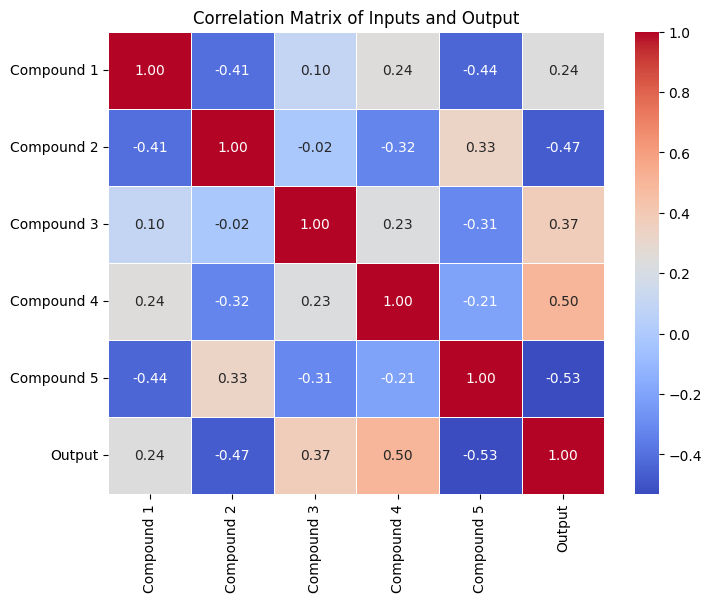


Correlation Analysis and Next Query Strategy:


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Check if lengths match, and truncate if necessary
# Find the minimum length between inputs and outputs
min_len = min(len(updated_inputs), len(updated_outputs))

# Truncate both arrays to the minimum length
updated_inputs = updated_inputs[:min_len]
updated_outputs = updated_outputs[:min_len]

# Print the lengths after truncation for verification (optional)
print(f"Lengths after truncation: updated_inputs = {len(updated_inputs)}, updated_outputs = {len(updated_outputs)}")

# Create a Pandas DataFrame
df = pd.DataFrame(updated_inputs, columns=['Compound 1', 'Compound 2', 'Compound 3', 'Compound 4', 'Compound 5'])
df['Output'] = updated_outputs # Now the lengths should match

# Calculate the correlation matrix
correlation_matrix = df.corr()

# Print the correlation matrix
print("Correlation Matrix:")
print(correlation_matrix)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Inputs and Output')
plt.show()

# Analyze correlations to inform next queries
print("\nCorrelation Analysis and Next Query Strategy:")

# 1. Identify strong correlations with the 'Output':
#    Look at the 'Output' row (or column) in the correlation matrix.
#    Positive correlation means as the input increases, the output tends to increase.
#    Negative correlation means as the input increases, the output tends to decrease.
#    Since we want the output to be close to 0 (which means making the negative output less negative, i.e., increasing the output value),
#    we would want to increase inputs with positive correlation and decrease inputs with negative correlation.

# 2. Consider the top performing inputs:
#    Review the ingredient combinations that resulted in outputs closest to 0.
#    Look for patterns in these successful combinations.

# 3. Formulate next query strategy:
#    Based on the correlation analysis and the patterns in top inputs,
#    propose new input combinations.

# Example strategy based on hypothetical correlation:
# If 'Compound 1' has a strong positive correlation with 'Output' and 'Compound 2' has a strong negative correlation,
# a possible strategy might be to increase 'Compound 1' and decrease 'Compound 2' from a current promising input point.

# You'll need to analyze the printed correlation matrix and the top inputs
# from the previous step to develop a specific strategy for your next queries.
# For instance, you might pick one of the top inputs and adjust its values
# based on the correlation coefficients to try to move the output closer to zero.

In [ ]:
import numpy as np

# Suggested queries
next_query_1 = np.array([0.69, 0.15, 0.76, 0.72, 0.03])
next_query_2 = np.array([0.70, 0.12, 0.75, 0.75, 0.02])
next_query_3 = np.array([0.70, 0.14, 0.75, 0.70, 0.04])

print("Suggested next queries (for Function 6 - Cake and Stuff, aiming for output close to 0):")
print(f"Query 1: {next_query_1}")
print(f"Query 2: {next_query_2}")
print(f"Query 3: {next_query_3}")

Suggested next queries (for Function 6 - Cake and Stuff, aiming for output close to 0):
Query 1: [0.69 0.15 0.76 0.72 0.03]
Query 2: [0.7  0.12 0.75 0.75 0.02]
Query 3: [0.7  0.14 0.75 0.7  0.04]


In [ ]:
import numpy as np

# Load existing data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# New data point
new_input = np.array([0.69, 0.15, 0.76, 0.72, 0.03])
new_output = np.float64(-0.704519228372214)

# Add new data to existing data
updated_inputs = np.vstack([updated_inputs, new_input])
updated_outputs = np.append(updated_outputs, new_output)

# Save updated data to files
np.save('/content/updated_inputs.npy', updated_inputs)
np.save('/content/updated_outputs.npy', updated_outputs)

print("Updated input and output files saved successfully!")

Updated input and output files saved successfully!


In [ ]:
import numpy as np

# Load updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the updated data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

Updated Inputs:
 [[0.7281861  0.15469257 0.73255167 0.69399651 0.05640131]
 [0.24238435 0.84409997 0.5778091  0.67902128 0.50195289]
 [0.72952261 0.7481062  0.67977464 0.35655228 0.67105368]
 [0.77062024 0.11440374 0.04677993 0.64832428 0.27354905]
 [0.6188123  0.33180214 0.18728787 0.75623847 0.3288348 ]
 [0.78495809 0.91068235 0.7081201  0.95922543 0.0049115 ]
 [0.14511079 0.8966846  0.89632223 0.72627154 0.23627199]
 [0.94506907 0.28845905 0.97880576 0.96165559 0.59801594]
 [0.12572016 0.86272469 0.02854433 0.24660527 0.75120624]
 [0.75759436 0.35583141 0.0165229  0.4342072  0.11243304]
 [0.5367969  0.30878091 0.41187929 0.38822518 0.5225283 ]
 [0.95773967 0.23566857 0.09914585 0.15680593 0.07131737]
 [0.6293079  0.80348368 0.81140844 0.04561319 0.11062446]
 [0.02173531 0.42808424 0.83593944 0.48948866 0.51108173]
 [0.43934426 0.69892383 0.42682022 0.10947609 0.87788847]
 [0.25890557 0.79367771 0.6421139  0.19667346 0.59310318]
 [0.43216593 0.71561781 0.3418191  0.70499988 0.6149618

In [ ]:
import numpy as np

# Load updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# 1. Find the Best Performing Inputs:
# Find the indices of the inputs that resulted in the lowest (closest to 0) outputs.
# You can adjust 'num_promising_inputs' to select more or fewer promising inputs.
num_promising_inputs = 2
# Ensure that the index does not exceed the size of updated_outputs
best_indices = np.argpartition(np.abs(updated_outputs), num_promising_inputs)[:num_promising_inputs]
best_indices = [index for index in best_indices if index < len(updated_inputs)]  # Filter out invalid indices

# Check if any valid indices remain:
if best_indices:
    promising_inputs = updated_inputs[best_indices]

    # 2. Generate Next Queries:
    next_queries = []

    # a. Average and Perturb:
    # Calculate the average of the promising inputs and add a small random perturbation.
    next_query_avg_perturbed = np.mean(promising_inputs, axis=0)
    perturbation = np.random.uniform(-0.02, 0.02, size=next_query_avg_perturbed.shape)
    next_query_avg_perturbed = next_query_avg_perturbed + perturbation
    next_query_avg_perturbed = np.clip(next_query_avg_perturbed, 0, 1)
    next_queries.append(next_query_avg_perturbed)

    # b. Explore Near Promising Inputs:
    # Generate additional queries by adding larger perturbations to individual promising inputs.
    perturbation_scale = 0.05  # Adjust as needed
    for input_point in promising_inputs:
        perturbation = np.random.uniform(-perturbation_scale, perturbation_scale, size=input_point.shape)
        next_query_explore = input_point + perturbation
        next_query_explore = np.clip(next_query_explore, 0, 1)
        next_queries.append(next_query_explore)

    # 3. Print or Use the Next Queries:
    print("Next Queries:")
    for i, query in enumerate(next_queries):
        print(f"Query {i + 1}: {query}")
else:
    print("No valid indices found for promising inputs. Check your data or adjust 'num_promising_inputs'.")

# Now you can use these 'next_queries' in your experiment.

Next Queries:
Query 1: [0.69310536 0.20302906 0.77178642 0.69502396 0.07960215]
Query 2: [0.64266721 0.24166549 0.74088347 0.69190955 0.06082927]
Query 3: [0.65625467 0.1807318  0.75906039 0.68024829 0.02846256]


In [1]:
import numpy as np

# Load updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Find the index of the output closest to 0
best_index = np.argmin(np.abs(updated_outputs))

# Get the corresponding input
best_input = updated_inputs[best_index]

# Print the results
print("Input with output closest to 0:")
print(best_input)
print("Output value:", updated_outputs[best_index])

Input with output closest to 0:
[0.70507  0.17811  0.751431 0.689813 0.062701]
Output value: -0.5982598004856436


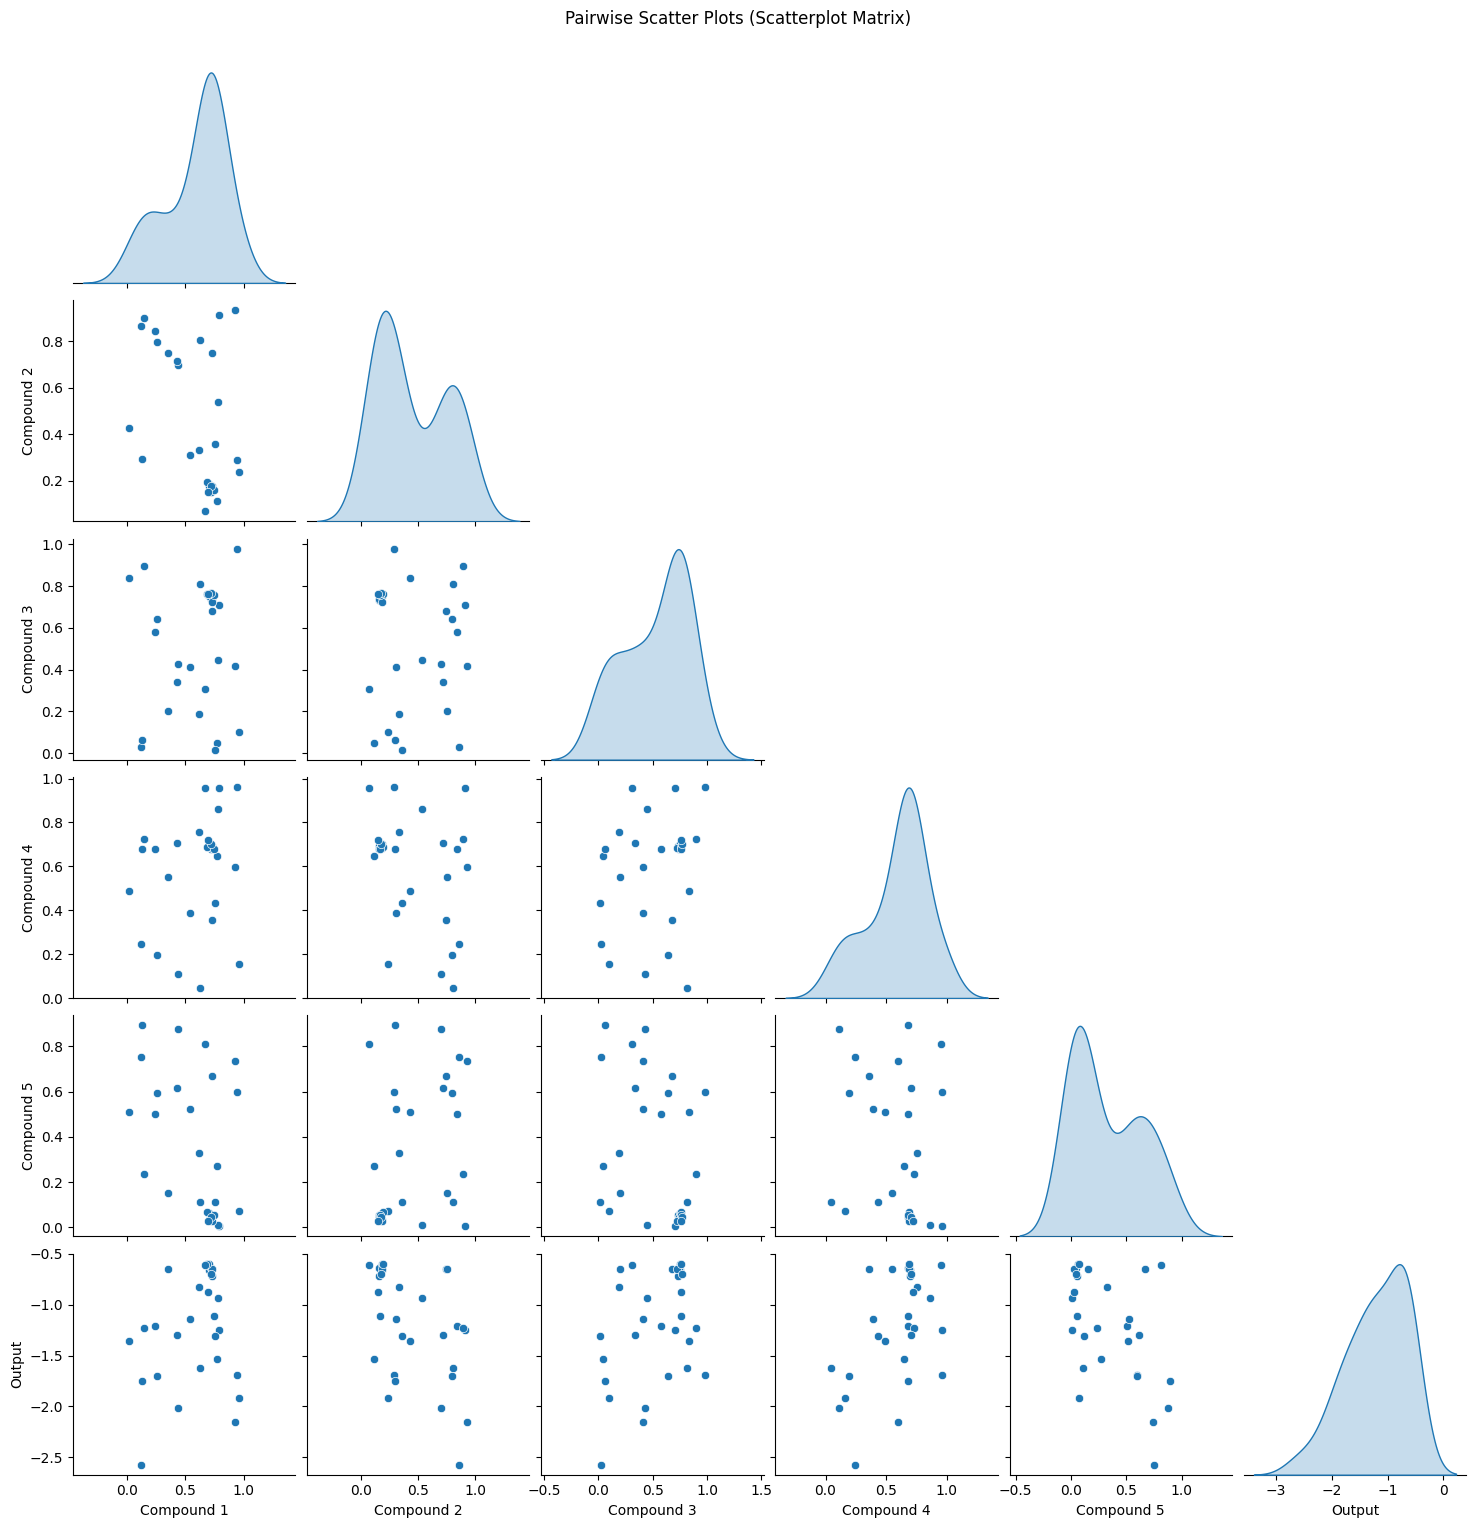

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Load data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Check if lengths match, and truncate if necessary
min_len = min(len(updated_inputs), len(updated_outputs))
updated_inputs = updated_inputs[:min_len]
updated_outputs = updated_outputs[:min_len]

# Create a Pandas DataFrame
df = pd.DataFrame(updated_inputs, columns=['Compound 1', 'Compound 2', 'Compound 3', 'Compound 4', 'Compound 5'])
df['Output'] = updated_outputs

# Create the scatterplot matrix
sns.pairplot(df, diag_kind='kde', corner=True)
plt.suptitle('Pairwise Scatter Plots (Scatterplot Matrix)', y=1.02)
plt.show()